# This notebook contains the code used to make the nonMTEX and non map figures in Part I. 

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import DiadFit as pf


## Loading in DeVitre and Wieser (2023) and DeVitre et al. (2024) data merged togetehr

In [68]:
df_kil_d=pd.read_excel('Online_Resource_1.xlsx', sheet_name='DeVitre_data_for_plotting')
df_kil_d.head()

## Now calculate depth
Depth=pf.convert_pressure_to_depth(P_kbar=df_kil_d['P_kbar'],  model='denlinger_lerner')
df_kil_d['Depth (km)']=Depth


## now calculate SO2 business


#df_kil_d=df_kil_d.loc[df_kil_d['Dataset']=='LERZ2018']
df_kil_d.tail()

df_K23=df_kil_d.loc[df_kil_d['Sample']=='K23']
df_L18=df_kil_d.loc[df_kil_d['Sample']=='LERZ2018']


## Loading in the 2022 data from Lynn et al. 

In [69]:
df_22=pd.read_excel('Online_Resource_1.xlsx', sheet_name='Lynn_data_for_plotting')

df_22['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,
                               A_SO2=df_22['Peak_Area_SO2'], A_CO2_Tot=(df_22['Diad1_Voigt_Area']+ df_22['Diad2_Voigt_Area']))
df_22['SO2_Burke_table_pref']=df_22['SO2_Burke_table_pref'].fillna(0)

## Loading in Mauna Loa data (this study)

In [70]:
df_FI_ML_all=pd.read_excel(r'Online_Resource_1.xlsx', sheet_name='FI_comp_data')

# lets filter out the ones with low fluid percent

df_FI_ML=df_FI_ML_all[~(df_FI_ML_all['% fluid'].fillna(100)<40)]
FI_1868=(df_FI_ML['eruption']==1868)
FI_1852=(df_FI_ML['eruption']==1852)
FI_1950=(df_FI_ML['eruption']==1950)
FI_1855=(df_FI_ML['eruption']==1855)
FI_1949=(df_FI_ML['eruption']==1949)
FI_1984=(df_FI_ML['eruption']==1984)

eruption=[7360, 1852, 1855, 1868,  1949, 1950, 1984, 2022]
erup_color=['white', 'red', 'salmon', 'yellow', 'green', 'darkred',  'grey', 'cyan']
erup_symbol=['o', 'p', '^', 'p', 'd', 's', 'o', '*']

## Code used to calculate SO2_mol_frac in the datatable
df_FI_ML['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,
                               A_SO2=df_FI_ML['Peak_Area_SO2'], A_CO2_Tot=(df_FI_ML['Diad1_Voigt_Area']+ df_FI_ML['Diad2_Voigt_Area']))
df_FI_ML['SO2_Burke_table_pref']=df_FI_ML['SO2_Burke_table_pref'].fillna(0)

# Splitting my data into Gaffney and historic

df_FI_ML_Gaff=df_FI_ML.loc[df_FI_ML['Fluid inclusion Name'].str.contains('AMG98')]
df_FI_ML_Hist=df_FI_ML.loc[~df_FI_ML['Fluid inclusion Name'].str.contains('AMG98')]


C:\Users\penny\AppData\Local\Temp\ipykernel_39952\1120836458.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FI_ML['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\1120836458.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FI_ML['SO2_Burke_table_pref']=df_FI_ML['SO2_Burke_table_pref'].fillna(0)


## Lets load in the ones from Part II which actually show phenocryst affinities from 48g

In [71]:
Ols_7360_FI=pd.read_excel(r'Online_Resource_1.xlsx', sheet_name='PartII_data_for_plotting')


## Figure 4 - Textural Parameters

7360
1852
1855
1868
1949
1950
1984
2022


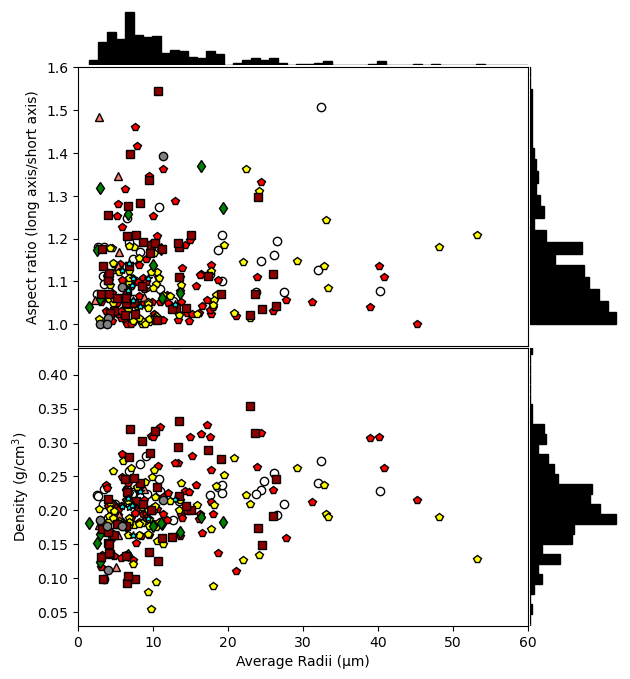

In [72]:
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax_hist_top, deadspace), (ax2, ax2_hist), (ax1, ax1_hist)) = plt.subplots(
    3, 2, figsize=(7, 8), 
    gridspec_kw={'width_ratios': [3, 0.6], 'height_ratios': [0.6, 3, 3], 'wspace': 0.01, 'hspace': 0.01}
)




for erup, col, sym in zip(eruption, erup_color, erup_symbol):
    print(erup)
    if erup ==7360:
        combined_radi = pd.concat([Ols_7360_FI['Av_radi'], df_FI_ML['Av_radi'].loc[df_FI_ML['eruption'] == erup]])
        combined_AR = pd.concat([Ols_7360_FI['Diff_size'], df_FI_ML['Diff_size'].loc[df_FI_ML['eruption'] == erup]])
        combined_dens = pd.concat([Ols_7360_FI['Density g/cm3'], df_FI_ML['Density g/cm3'].loc[df_FI_ML['eruption'] == erup]])
        ax1.plot(combined_radi, combined_dens,
                sym, mec='k', mfc=col, label=erup)
        
        ax2.plot(combined_radi, combined_AR,
                sym, mec='k', mfc=col, label=erup)
    

    else:
        ax1.plot(df_FI_ML['Av_radi'].loc[df_FI_ML['eruption'] == erup], df_FI_ML['Density g/cm3'].loc[df_FI_ML['eruption'] == erup],
                sym, mec='k', mfc=col, label=erup)
        
        ax2.plot(df_FI_ML['Av_radi'].loc[df_FI_ML['eruption'] == erup], df_FI_ML['Diff_size'].loc[df_FI_ML['eruption'] == erup],
                sym, mec='k', mfc=col, label=erup)
    



ax2.set_ylabel('Aspect ratio (long axis/short axis)')
#ax2.set_xlabel('Average Radi (μm)')

# Setting ranges
min_dens=0
max_dens=np.max(df_FI_ML['Density g/cm3'])+0.02

min_radi=0
max_radi=np.max(df_FI_ML['Av_radi'])+1

max_ar=np.max(df_FI_ML['Diff_size'])+0.05

# Setting x axes to all be the same


# Setting y axes of hist and plot to be the same


# ax2_hist.set_ylim([0.99, max_ar])

# Very top histogram - Showing Radii

## Setting up the histograms 
combined_radi = pd.concat([Ols_7360_FI['Av_radi'], df_FI_ML['Av_radi']])
combined_AR = pd.concat([Ols_7360_FI['Diff_size'], df_FI_ML['Diff_size']])
combined_dens = pd.concat([Ols_7360_FI['Density g/cm3'], df_FI_ML['Density g/cm3']])


ax_hist_top.hist(combined_radi, bins=100, ec='k', facecolor='black')
ax_hist_top.axes.get_xaxis().set_visible(False)
ax_hist_top.axes.get_yaxis().set_visible(False)
ax_hist_top.axis("off")


# Histograms for ax2 - On right hand side, showing aspect ratio
ax2_hist.hist(combined_AR, bins=30, orientation='horizontal', ec='k', facecolor='black')
ax2_hist.axes.get_xaxis().set_visible(False)
ax2_hist.axes.get_yaxis().set_visible(False)
ax2_hist.axis("off")

ax1_hist.hist(combined_dens, bins=30, orientation='horizontal', ec='k', facecolor='black')
ax1_hist.axes.get_xaxis().set_visible(False)
ax1_hist.axes.get_yaxis().set_visible(False)
ax1_hist.axis("off")
# Histograms for ax2
#ax2_hist.hist(df_FI_ML['Diff_size'], bins=30, orientation='horizontal')
deadspace.axes.get_xaxis().set_visible(False)
deadspace.axes.get_yaxis().set_visible(False)
deadspace.axis("off")
ax2.axes.get_xaxis().set_visible(False)


#ax2.legend()

## ax1 limits , e.g. bottom left
ax1.set_ylim([0.03, 0.44])
ax1_hist.set_ylim([0.03, 0.44])
ax1.set_xlim([0, 60])
ax_hist_top.set_xlim([0, 60])
ax1.set_xlim([0, 60])



# Ax2 limits, top right
ax2.set_ylim([0.95, 1.6])
ax2_hist.set_ylim([0.95, 1.6])
ax2.set_xlim([0, 60])






ax1.set_xlabel('Average Radii (μm)')
ax1.set_ylabel('Density (g/cm$^{3}$)')



fig.savefig('FluidInclusion_TexturalParameters_Historic.png', transparent=True, dpi=200)


## Depth plot histogram

In [73]:
def depth_to_pressure(D_km):
    # Coefficients of the cubic equation for depth to pressure
    coefficients = [0.0684, -0.5008, 4.47, -D_km]
    # Find the roots of the polynomial
    roots = np.roots(coefficients)
    # Filter for real, positive roots
    real_positive_roots = np.real(roots[np.isreal(roots) & (roots > 0)])
    
    if real_positive_roots.size > 0:
        # Return the first real, positive root
        return real_positive_roots[0]
    else:
        # If no valid roots, return NaN or some default value
        return np.nan

In [74]:
# this is because there are repeats, as 2022 data in Kendras supplement
df_FI_ML_not2022=df_FI_ML.loc[df_FI_ML['eruption']!=2022]
df_FI_ML_not2022['SO2_Burke_table_pref']=df_FI_ML_not2022['SO2_Burke_table_pref']

df_79e = Ols_7360_FI
data_79e= df_79e['D(km)_HC']


# # The 7360 ones are on the df_FI_ML now, should be removed from Gaffney.....

# # Concatenate into a single Series
# data_hist = df_FI_ML_not2022
# data_hist_crystal=pd.concat([df_FI_ML_not2022['crystal'], df_22['crystal']])
# # Create a DataFrame with the combined data
df_2022=pd.DataFrame({'D(km)_HC': df_22['SingleFI_D_km']})
df_2022['SO2_Burke_table_pref']=df_22['SO2_Burke_table_pref']
df_2022['crystal']=df_22['crystal']
# df_hist = pd.DataFrame({'D(km)_HC': data_hist })

# df_xenolith['Group'] = 'Xenolith'
# df_hist['Group'] = 'Historic'
df_2022['Group']='Historic'
df_combo_hist=pd.concat([ df_2022['D(km)_HC'], df_FI_ML_not2022['D(km)_HC']])

df_combo_hist_SO2=pd.concat([ df_2022['SO2_Burke_table_pref'], df_FI_ML_not2022['SO2_Burke_table_pref']])

df_combo_hist_cryst=pd.concat([ df_2022['crystal'], df_FI_ML_not2022['crystal']])



C:\Users\penny\AppData\Local\Temp\ipykernel_39952\454214150.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FI_ML_not2022['SO2_Burke_table_pref']=df_FI_ML_not2022['SO2_Burke_table_pref']


## Figure 11 - Top Row

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2587538825.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_22, y="SingleFI_D_km", cut=0, inner='stick',


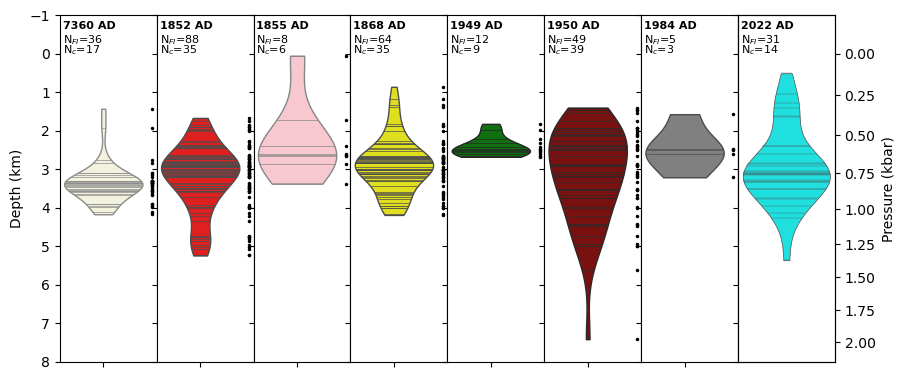

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the eruption years, colors, and symbols for df_FI_ML
eruption = [7360, 1852, 1855, 1868, 1949, 1950, 1984]
erup_color = ['beige', 'red', 'pink', 'yellow', 'green', 'darkred', 'grey']





# Create the subplots
fig, ((ax3g, ax3a, ax3b, ax3c, ax3d, ax3e, ax3f,ax3k2 )) = plt.subplots(
    1, 8, figsize=(10, 4.5), sharey=True, sharex=False,
    gridspec_kw={'width_ratios': [0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7]}
)
plt.subplots_adjust(wspace=0, hspace=0)

# Loop through each eruption year and corresponding color for df_FI_ML
for i, year in enumerate(eruption):
    ax = [ax3g, ax3a, ax3b, ax3c, ax3d, ax3e, ax3f][i]
    color = erup_color[i]
    
    # Plot the violin plot using seaborn
    data = df_FI_ML[df_FI_ML['eruption'] == year]
    sns.violinplot(y='D(km)_HC', data=data, ax=ax, color=color,  inner="stick", cut=0,  linewidth=1)
    
    # Add the sticks using swarmplot or stripplot
    #sns.stripplot(y='D(km)_HC', data=data, ax=ax, color='black', jitter=False, size=3, linewidth=0.5)
    maxy=0.5
    xp=maxy+0*df_FI_ML['D(km)_HC'].loc[df_FI_ML['eruption']==year]
    ax.plot(xp, 
            df_FI_ML['D(km)_HC'].loc[df_FI_ML['eruption']==year], 
            '.', color='k', ms=3)
    
    
    # # Add the sticks using swarmplot or stripplot
    # sns.stripplot(y='D(km)_HC', data=data, ax=ax, color='black', jitter=False, size=3, linewidth=0.5)
    # Add an error bar
        # Get average and std of Density for this eruption



    # Add annotations
    xann=0.03
    ax.annotate(str(year) + ' AD', xy=(xann, 0.96), xycoords="axes fraction", fontsize=8, fontweight='bold')
    ax.annotate("N$_{FI}$=" + str(sum(data['D(km)_HC'] > 0)), 
                xy=(xann, 0.92), xycoords="axes fraction", fontsize=8)
    ax.annotate("N$_{c}$=" + str(len(data['crystal'].unique())), 
                xy=(xann, 0.89), xycoords="axes fraction", fontsize=8)


# Concatenate the two dataframes vertically (row-wise)
    #combined_depths_G = pd.concat([data_B_selected, data_P_selected], ignore_index=True)





# #ax.set_xlim([-0.5, 1])




sns.violinplot(data=df_22, y="SingleFI_D_km", cut=0, inner='stick', 
                ax=ax3k2, width=0.9, palette=["cyan"], linewidth=0.5)
ax3k2.annotate('2022 AD', xy=(xann, 0.96), xycoords="axes fraction", fontsize=8, fontweight='bold')
ax3k2.annotate("N$_{FI}$=" + str(sum(df_22['SingleFI_D_km'] > 0)), 
                xy=(xann, 0.92), xycoords="axes fraction", fontsize=8)
ax3k2.annotate("N$_{c}$=" + str(len(df_22['crystal'].unique())), 
                xy=(xann, 0.89), xycoords="axes fraction", fontsize=8)

ax3k2.set_xticks([])
ax3k2.set_xlabel('')


def pressure_to_depth(P_kbar):
    return 0.0684*P_kbar**3 - 0.5008*P_kbar**2 + 4.47*P_kbar

# Define nice pressure ticks and corresponding depth
pressure_ticks = np.array([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2.0])  # Example values, can be adjusted
depth_ticks = [pressure_to_depth(P) for P in pressure_ticks]

# Add the secondary y-axis on the right
ax3g.set_ylim([8, -1])
ax = ax3k2
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_ylabel('Pressure (kbar)')

# Set the ticks on the right y-axis to correspond to the nice pressure values
ax2.set_yticks(depth_ticks)
ax2.set_yticklabels([f'{P:.2f}' for P in pressure_ticks])
ax3g.set_ylabel('Depth (km)')




fig.savefig('Pressures_Depths.png', dpi=300, transparent=True)

## summary ones

In [76]:
# # of crystal to label figure 11 with
print(len(df_K23['Crystal'].unique()))
print(len(df_K23))
# Same for 2018
print(len(df_L18['Crystal'].unique()))
print(len(df_L18))

32
62
47
102


In [77]:
from scipy.stats import ks_2samp

# Perform the KS test
ks_statistic, p_value = ks_2samp(df_FI_ML['SingleCalc_P_kbar'], df_kil_d['P_kbar'])

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpretation of results
if p_value < 0.05:
    print("The two distributions are statistically distinct (reject the null hypothesis).")
else:
    print("The two distributions are not statistically distinct (fail to reject the null hypothesis).")


KS Statistic: 0.714719647196472
P-value: 4.846300008867569e-51
The two distributions are statistically distinct (reject the null hypothesis).


## Figure 11 part b-d)

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\4022792164.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\4022792164.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\4022792164.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\4022792164.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

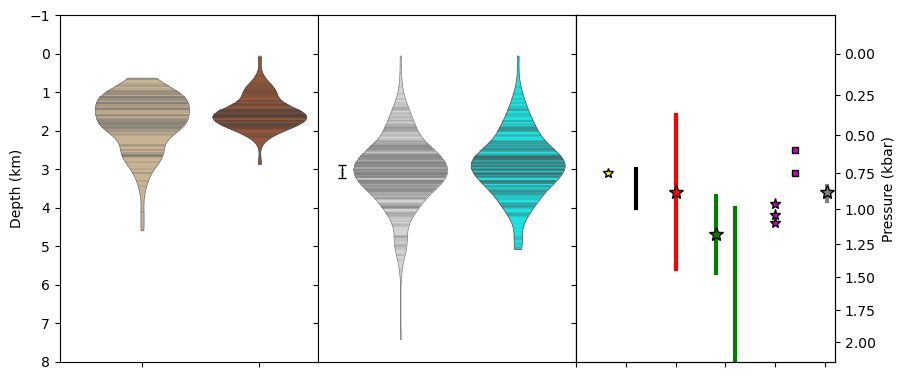

In [78]:
import seaborn as sns


# === Combine combo hist and SO2 into single DataFrame ===
df_combo_hist_full = pd.DataFrame({
    'D(km)_HC': df_combo_hist,
    'SO2_Burke_table_pref': df_combo_hist_SO2,
    'crystal': df_combo_hist_cryst,
})

# Subsets
df_all = df_combo_hist_full.copy()
df_lt5 = df_combo_hist_full[df_combo_hist_full['SO2_Burke_table_pref'] == 0].copy()

# Add group columns for x-shifting
df_all['x'] = -0.2  # left side of violin
df_lt5['x'] = 0.2   # right side of violin

# === Create figure and subplots ===
fig, ((ax3i, ax3k2, ax3l)) = plt.subplots(
    1, 3, figsize=(10, 4.5), sharey=True, sharex=False,
    gridspec_kw={'width_ratios': [0.7, 0.7, 0.7]}
)
plt.subplots_adjust(wspace=0, hspace=0)

sns.violinplot(
    data=df_L18, x=0, y='Depth (km)',
    cut=0, inner='stick', width=0.8,
    palette=['tan'], linewidth=0.5, ax=ax3i
)
sns.violinplot(
    data=df_K23, x=1, y='Depth (km)',
    cut=0, inner='stick', width=0.8,
    palette=['sienna'], linewidth=0.5, ax=ax3i
)

ax3i.set_xlim([-0.7, 2])
ax3i.set_xticklabels([])
ax3i.set_xlabel('')
ax3i.set_ylabel('Depth (km)')

# === MIDDLE PANEL: Left = All, Right = <5 mol% SO₂ ===
sns.violinplot(
    data=df_all, x=0, y='D(km)_HC',
    cut=0, inner='stick', width=0.8,
    palette=['lightgrey'], linewidth=0.5, ax=ax3k2
)
sns.violinplot(
    data=df_lt5, x=1, y='D(km)_HC',
    cut=0, inner='stick', width=0.8,
    palette=['cyan'], linewidth=0.5, ax=ax3k2
)

# Error bar on left violin (at x = -0.2)
ax3k2.errorbar(
    x=-0.5,
    y=np.nanmean(df_FI_ML['D(km)_HC']),
    xerr=0,
    yerr=np.nanmean(df_FI_ML['D(km)_HC_err']),
    fmt=',', ecolor='k', elinewidth=0.8, capsize=3
)

ax3k2.set_xlim([-0.7, 1.5])
ax3i.set_xlim([-0.7, 1.5])

ax3k2.set_xticks([])
ax3k2.set_xlabel('')

# === RIGHT PANEL: Geophysical references ===
x = -0.6
x_space = 0.2

ax3l.plot(x + x_space * 1.3, 3.1, '*k', mfc='yellow', ms=7, label='Decker et al. 1983 (just tilt)')
ax3l.plot([x + 2 * x_space, x + 2 * x_space], [3, 4], '-k', lw=3, label='Decker et al. 1983 (coinversion)')
ax3l.plot([x + 3 * x_space, x + 3 * x_space], [1.6, 5.6], '-r', lw=3, label='Yun et al. (2005) InSAR')
ax3l.plot(x + 3 * x_space, 3.6, '*k', mfc='r', ms=10)
ax3l.plot([x + 4 * x_space, x + 4 * x_space], [3.7, 5.7], '-g', lw=3, label='Amelung spherical chamber')
ax3l.plot(x + 4 * x_space, 4.7, '*k', mfc='green', ms=10)
ax3l.plot([x + 4.5 * x_space, x + 4.5 * x_space], [4, 8], '-g', lw=3, label='Amelung dike')
ax3l.plot([x + 5.5 * x_space], [4.4], '*k', lw=3, ms=8, mfc='m', label='Varugu Mogi')
ax3l.plot([x + 5.5 * x_space], [4.2], '*k', lw=3, ms=8, mfc='m', label='Varugu Mogi')
ax3l.plot([x + 5.5 * x_space], [3.9], '*k', lw=3, ms=8, mfc='m', label='Varugu Mogi')
ax3l.plot([x +6 * x_space], [3.1], 'sk', lw=3, ms=5, mfc='m', label='Varugu dyke')
ax3l.plot([x + 6* x_space], [2.5], 'sk', lw=3, ms=5, mfc='m', label='Varugu dyke')


ax3l.plot([x + 6.8 * x_space, x + 6.8 * x_space], [3.43, 3.83], '-', c='grey', lw=3, label='Johnson (1995)')
ax3l.plot(x + 6.8 * x_space, 3.6, '*k', mfc='grey', ms=10)

ax3l.set_xlim([-0.5, 0.8])

#ax3l.set_xlim([-0.5, 0.6])
ax3l.set_xticklabels([])
ax3l.set_ylim([8, -1])
ax3l.set_xlabel('')

# === SECONDARY Y-AXIS: Pressure ===
def pressure_to_depth(P_kbar):
    return 0.0684 * P_kbar ** 3 - 0.5008 * P_kbar ** 2 + 4.47 * P_kbar

pressure_ticks = np.array([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2.0])
depth_ticks = [pressure_to_depth(P) for P in pressure_ticks]

ax2 = ax3l.twinx()
ax2.set_ylim(ax3l.get_ylim())
ax2.set_ylabel('Pressure (kbar)')
ax2.set_yticks(depth_ticks)
ax2.set_yticklabels([f'{P:.2f}' for P in pressure_ticks])

# === SAVE FIGURE ===
fig.savefig('Pressures_Depths_summary.png', dpi=300, transparent=True)


## Mineral Chemistry

In [79]:
import Thermobar as pt

df_MG_USGS=pd.read_excel(r'Online_Resource_1.xlsx', 
                      sheet_name='USGS_glass_oxides')

df_MG_UCB=pd.read_excel(r'Online_Resource_1.xlsx', 
                      sheet_name='UCBerkeley_glass_oxides')

df_noFI=pd.read_excel(r'Online_Resource_1.xlsx', 
                      sheet_name='Minerals_without_FIs')

df_MG_c=pd.concat([df_MG_USGS, df_MG_UCB], axis=0)
df_MG_Thermobar=pt.import_excel('None', 'None', df=df_MG_c.reset_index(drop=True))
df_MG=df_MG_Thermobar['my_input']
df_MG.head()

,Eruption,Sample Name,SiO2_Liq,Na2O_Liq,CaO_Liq,K2O_Liq,FeOt_Liq,Al2O3_Liq,MgO_Liq,TiO2_Liq,...,#_ions__Cu,#_ions__Al,#_ions__Ti,#_ions__Cr,#_ions__Na,#_ions__K,#_ions__S,#_ions__V,#_ions__P,SampleID
0,1852,L-86-281_gl1 Ave,51.936309,2.527860,10.267962,0.487681,10.136825,13.936775,7.435175,2.057233,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1852,L-86-281_gl2 Ave,52.037621,2.393357,10.241605,0.453324,10.185483,13.920325,7.555887,2.039570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1852,L-86-281_gl3 Ave,51.583338,2.530797,10.444717,0.466343,10.620175,13.873050,7.754073,2.038190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1852,L-86-281_gl4 Ave,52.514343,2.437470,10.287810,0.436450,10.127225,13.822875,7.800933,2.084138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1868,L-93-208_gl1 Ave,52.852239,1.405670,10.716706,0.413601,10.632375,14.390375,7.196777,2.081208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
conditions = [
    df_noFI['SAMPLE'].str.contains('M85', na=False),
    df_noFI['SAMPLE'].str.contains('M84', na=False),
    df_noFI['SAMPLE'].str.contains('M49', na=False),
    df_noFI['SAMPLE'].str.contains('MP2', na=False),
    df_noFI['SAMPLE'].str.contains('MLP', na=False),
]
choices = [1855, 1984, 1949, 1852, 1868]

# Create the new column 'Eruption'
df_noFI['Eruption'] = np.select(conditions, choices, default=np.nan)

In [81]:
df_noFI['Eruption'].unique()

array([1855., 1984., 1949., 1852., 1868.])

In [82]:
df_noFI2=df_noFI.copy()
new_columns = [col.replace('_cpxprim', '_useme') for col in df_noFI2.columns]

# Rename the columns in the DataFrame
df_noFI2.columns = new_columns
df_no_FI_sim = df_noFI2[[col for col in df_noFI2.columns if '_useme' in col]]
df_no_FI_sim['Sample']=df_noFI2['SAMPLE']

Ol_index=df_no_FI_sim['MgO_useme']>40
Plag_index=df_no_FI_sim['Al2O3_useme']>25
Opx_index=df_no_FI_sim['CaO_useme'].between(1,5 )



C:\Users\penny\AppData\Local\Temp\ipykernel_39952\408981458.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_FI_sim['Sample']=df_noFI2['SAMPLE']


In [83]:
# Glass Mg#
df_MG['H2O_Liq']=0.3
df_MG['Mg#']=pt.calculate_liq_mgno(liq_comps=df_MG, Fe3Fet_Liq=0.15)
# Equilibrium olivine contents
df_MG['T_Shea']=pt.calculate_liq_only_temp(equationT='T_Shea2022_MgO', liq_comps=df_MG)

Eq_Plag=pt.calculate_eq_plag_An_number(liq_comps=df_MG,
                                           P=0.5, T=df_MG['T_Shea'], An_model='All')

# USGS glass data
df_MG_1852=df_MG.loc[df_MG['Eruption']==1852]
df_MG_1868=df_MG.loc[df_MG['Eruption']==1868]
df_MG_1984=df_MG.loc[df_MG['Eruption']==1984]
df_MG_1855=df_MG.loc[df_MG['Eruption']==1855]
df_MG_2022=df_MG.loc[df_MG['Eruption']==2022]
# UCB glass data 
df_MG_1949=df_MG.loc[df_MG['Eruption']==1949]
df_MG_1950=df_MG.loc[df_MG['Eruption']==1950]
df_MG_1885=df_MG.loc[df_MG['Eruption']==1855]

In [84]:
df_Ols_noFI=df_noFI.loc[Ol_index].reset_index(drop=True)
df_Opxs_noFI=df_noFI.loc[Opx_index].reset_index(drop=True)
df_Plags_noFI=df_noFI.loc[Plag_index].reset_index(drop=True)

Ols_1949_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('M49')]
Ols_1855_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('M85')]
Ols_1984_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('M84')]
Ols_1852_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('MP2')]
Ols_1868_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('MLP')]
Ols_2022_noFI=df_Ols_noFI.loc[df_Ols_noFI['SAMPLE'].str.contains('22')]

df_FI_ML_all['Fo']=(df_FI_ML_all['MgO']/40.3044)/( (df_FI_ML_all['MgO']/40.3044) + (df_FI_ML_all['FeOt']/71.844) )
Ols_1949_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('M49')]
Ols_1950_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('M58')]
Ols_1855_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('M85')]
Ols_1984_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('M84')]
Ols_1852_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('MP2')]
Ols_1868_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('MLP')]
Ols_2022_FI=df_FI_ML_all.loc[df_FI_ML_all['filename'].str.contains('22')]

Ols_7360_FI_Gaff=Ols_7360_FI

Ols_7360_FI_PW=df_FI_ML.loc[df_FI_ML['filename'].str.contains('79e')]

### Calculating olivine equilibrium conditions

In [85]:
import Thermobar as pt
Rhodes=pt.calculate_ol_rhodes_diagram_lines(Min_Mgno=0.45, Max_Mgno=0.65)
Rhodes.head()

,Mg#_Liq,Eq_Ol_Fo_Roeder (Kd=0.3),Eq_Ol_Fo_Roeder (Kd=0.27),Eq_Ol_Fo_Roeder (Kd=0.33),Eq_Ol_Fo_Matzen (Kd=0.34),Eq_Ol_Fo_Matzen (Kd=0.328),Eq_Ol_Fo_Matzen (Kd=0.352),Eq_Ol_Fo_Shea (Kd=0.335),Eq_Ol_Fo_Shea (Kd=0.345),Eq_Ol_Fo_Shea (Kd=0.325)
0,0.450000,0.731707,0.751880,0.712589,0.706436,0.713832,0.699192,0.709499,0.703400,0.715706
1,0.452020,0.733306,0.753399,0.714257,0.708126,0.715496,0.700905,0.711178,0.705099,0.717363
2,0.454040,0.734897,0.754910,0.715918,0.709808,0.717153,0.702612,0.712850,0.706792,0.719013
3,0.456061,0.736482,0.756414,0.717572,0.711483,0.718803,0.704311,0.714515,0.708477,0.720656
4,0.458081,0.738058,0.757911,0.719219,0.713151,0.720445,0.706004,0.716172,0.710156,0.722292


### calculating pyroxene equilibrium conditions

In [86]:
Opx_lines=pt.calculate_opx_rhodes_diagram_lines(
        Min_Mgno=0.45, Max_Mgno=0.65, liq_comps=df_MG)
Opx_lines.head()

,Mg#_Liq,Eq_Opx_Mg# (Kd=0.23),Eq_Opx_Mg# (Kd=0.29),Eq_Opx_Mg# (Kd=0.35),Kd_XSi_P2008,Eq_Opx_Mg# (Kd_XSi_P2008),Eq_Opx_Mg# (Kd_XSi_P2008)+0.06,Eq_Opx_Mg# (Kd_XSi_P2008)-0.06
0,0.450000,0.780572,0.738310,0.700389,0.296839,0.733781,0.696312,0.775512
1,0.452020,0.781967,0.739883,0.702098,0.296839,0.735372,0.698035,0.776929
2,0.454040,0.783354,0.741449,0.703801,0.296839,0.736956,0.699751,0.778339
3,0.456061,0.784733,0.743008,0.705496,0.296839,0.738532,0.701459,0.779742
4,0.458081,0.786105,0.744559,0.707185,0.296839,0.740101,0.703161,0.781137


## Figure 7 part c-e

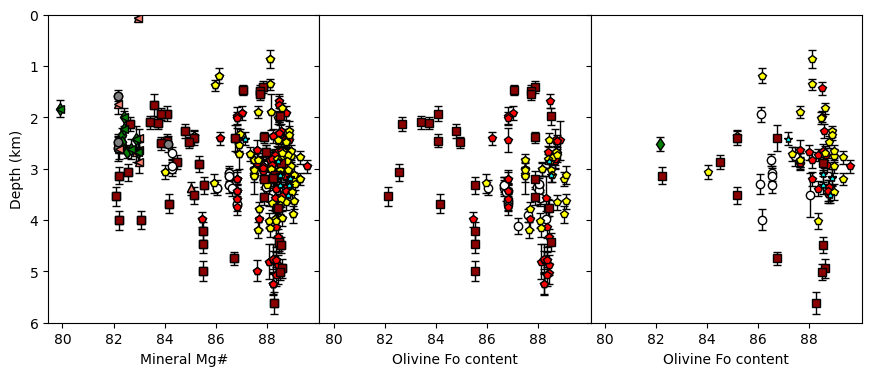

In [126]:

import matplotlib.gridspec as gridspec

# Create figure with three subplots in a row, sharing y-axis
fig, (ax1, ax0, ax2) = plt.subplots(1, 3, figsize=(10.5, 4), sharex=True, sharey=True)

# Remove space between ax0 and ax2
plt.subplots_adjust(wspace=0)


eruption=[7360, 1852, 1855, 1868,  1949, 1950, 1984, 2022]
erup_color=['white', 'red', 'salmon', 'yellow', 'green', 'darkred',  'grey', 'cyan']
erup_symbol=['o', 'p', '^', 'p', 'd', 's', 'o', '*']

for erup, col, sym in zip(eruption, erup_color, erup_symbol):
   
    px=df_FI_ML['CaO']>0.4
    df=df_FI_ML.loc[~px]

    y1=df['D(km)_HC'].loc[df['eruption']==erup]
    x1=100*df['Mg#'].loc[df['eruption']==erup]
    y1_err=df['D(km)_HC_err'].loc[df['eruption']==erup]
    
    ax1.plot(x1, y1, sym, mfc=col, mec='k', label=erup)
    ax1.errorbar(x1, y1, yerr=y1_err, fmt=sym, mfc=col, mec='k',
             ecolor='k', capsize=3, elinewidth=1, markeredgewidth=1)
    

    # Also plot 79e
    
    
    


    df_px=df_FI_ML.loc[px]
    y2=df_px['D(km)_HC'].loc[df_px['eruption']==erup]
    x2=100*df_px['Mg#'].loc[df_px['eruption']==erup]
    y2_err=df_px['D(km)_HC_err'].loc[df_px['eruption']==erup]
    ax1.plot(x2, y2, '<', mfc=col, mec='k', label=erup,  ms=6, zorder=100)
    ax1.errorbar(x2, y2, yerr=y2_err, fmt=sym, mfc=col, mec='k',
             ecolor='k', capsize=3, elinewidth=1, markeredgewidth=1)
    

## Plotting 79e

## This causes issues.
ax1.errorbar(
             100*Ols_7360_FI['Fo'],
             Ols_7360_FI['D(km)_HC'], 
              yerr=Ols_7360_FI['D(km)_HC_err'], fmt='ok', mfc='white', mec='k',
             ecolor='k', capsize=3, elinewidth=1, markeredgewidth=1)







########### - NOW LETS SHOW DEFORMED VS UNDEFORMED NEXT ################################3
## Second plot, showing depth vs. Fo content

for erup, col, symb in zip(eruption, erup_color, erup_symbol):

    y1=df_FI_ML_all['D(km)_HC'].loc[(df_FI_ML_all['eruption']==erup)&(df_FI_ML_all['Deformed']=='Y') ]
    x1=100*df_FI_ML_all['Fo'].loc[(df_FI_ML_all['eruption']==erup)&(df_FI_ML_all['Deformed']=='Y')]
    y1_err=df_FI_ML_all['D(km)_HC_err'].loc[(df_FI_ML_all['eruption']==erup)&(df_FI_ML_all['Deformed']=='Y') ]
    ax0.errorbar(x1, y1, yerr=y1_err, fmt=symb, mfc=col, mec='k',
             ecolor='k', capsize=3, elinewidth=1, markeredgewidth=1)
    

    #ax2.set_xscale('log')

for erup, col, symb in zip(eruption, erup_color, erup_symbol):

    y1=df_FI_ML_all['D(km)_HC'].loc[(df_FI_ML_all['eruption']==erup)&((df_FI_ML_all['Deformed']=='N')|(df_FI_ML_all['Deformed']=='S')) ]
    x1=100*df_FI_ML_all['Fo'].loc[(df_FI_ML_all['eruption']==erup)&((df_FI_ML_all['Deformed']=='N')|(df_FI_ML_all['Deformed']=='S'))]
    y1_err=df_FI_ML_all['D(km)_HC_err'].loc[(df_FI_ML_all['eruption']==erup)&((df_FI_ML_all['Deformed']=='N')|(df_FI_ML_all['Deformed']=='S')) ]
    ax2.errorbar(x1, y1, yerr=y1_err, fmt=symb, mfc=col, mec='k',
             ecolor='k', capsize=3, elinewidth=1, markeredgewidth=1)
# ax0.set_title('Deformed')
# ax2.set_title('Not Deformed')


ax1.set_ylabel('Depth (km)')
ax1.set_xlabel('Mineral Mg#')
ax2.set_xlabel('Olivine Fo content')
ax0.set_xlabel('Olivine Fo content')
ax1.set_ylabel('Depth (km)')
ax1.set_yticks([0, 1, 2, 3, 4, 5, 6])
ax0.set_xticks([80, 82, 84, 86, 88])
ax1.set_xticks([80, 82, 84, 86, 88])
ax2.set_xticks([80, 82, 84, 86, 88])

ax0.set_ylim([6, 0])
ax1.set_ylim([6, 0])
ax2.set_ylim([6, 0])

fig.savefig('DepthvsX.png', dpi=300, transparent=True)

## Figure 7 a-b

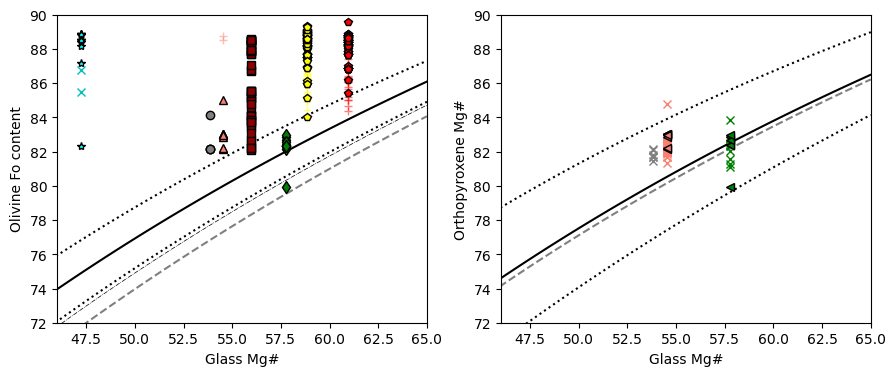

In [118]:

import matplotlib.gridspec as gridspec

# Create figure with three subplots in a row, sharing y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True, sharex=True)


## Lets plot the Rhodes diagram on ax1.

# Plotting equilibrium lines
ax1.plot(100*Rhodes['Mg#_Liq'], 100*Rhodes['Eq_Ol_Fo_Roeder (Kd=0.27)'], ':k')
ax1.plot(100*Rhodes['Mg#_Liq'], 100*Rhodes['Eq_Ol_Fo_Roeder (Kd=0.3)'], '-k')
ax1.plot(100*Rhodes['Mg#_Liq'], 100*Rhodes['Eq_Ol_Fo_Roeder (Kd=0.33)'], ':k')
ax1.plot(100*Rhodes['Mg#_Liq'], 100*Rhodes['Eq_Ol_Fo_Matzen (Kd=0.352)'], '--', c='grey')
ax1.plot(100*Rhodes['Mg#_Liq'], 100*Rhodes['Eq_Ol_Fo_Shea (Kd=0.335)'], '-.', c='k', lw=0.5)


# Plotting for FI then No FI for 1852
ax1.plot(100*np.nanmean(df_MG_1852['Mg#'])+ 0*Ols_1852_noFI['Fo'],100*Ols_1852_noFI['Fo'], '+', mec='red' , alpha=0.5, label='1852 no FI')
ax1.plot(100*np.nanmean(df_MG_1852['Mg#'])+ 0*Ols_1852_FI['Fo'],100*Ols_1852_FI['Fo'], 'pk', mfc='red' , label='1852 FI')

# Plotting for FI then no FI for 1855
ax1.plot(np.nanmean(100*df_MG_1855['Mg#'])+ 0*Ols_1855_noFI['Fo'],100*Ols_1855_noFI['Fo'], '+', mec='salmon' , alpha=0.5,label='1855 no FI')
ax1.plot(np.nanmean(100*df_MG_1855['Mg#'])+ 0*Ols_1855_FI['Fo'],100*Ols_1855_FI['Fo'], '^k', mfc='salmon' , label='1855 FI')

# 1868 
ax1.plot(100*np.nanmean(df_MG_1868['Mg#'])+ 0*Ols_1868_noFI['Fo'],100*Ols_1868_noFI['Fo'], '+', mec='yellow' ,alpha=0.5, label='1868 no FI')
ax1.plot(100*np.nanmean(df_MG_1868['Mg#'])+ 0*Ols_1868_FI['Fo'],100*Ols_1868_FI['Fo'], 'pk', mfc='yellow' , label='1868 FI')

# 1949
ax1.plot(100*np.nanmean(df_MG_1949['Mg#'])+ 0*Ols_1949_noFI['Fo'],100*Ols_1949_noFI['Fo'], '+', mec='g' , alpha=0.5, label='1949 no FI')
ax1.plot(100*np.nanmean(df_MG_1949['Mg#'])+ 0*Ols_1949_FI['Fo'],100*Ols_1949_FI['Fo'], 'dk', mfc='g' , label='1949 FI')
# 

# 1950
#ax1.plot(np.nanmean(df_MG_1950['Mg#'])+ 0*Ols_1950_noFI['Fo'],Ols_1950_noFI['Fo'], 'sk', mfc='darkred' , alpha=0.5, label='1950')
ax1.plot(100*np.nanmean(df_MG_1950['Mg#'])+ 0*Ols_1950_FI['Fo'],100*Ols_1950_FI['Fo'], 'sk', mfc='darkred' , label='1950 FI')

# 1984
ax1.plot(100*np.nanmean(df_MG_1984['Mg#'])+ 0*Ols_1984_noFI['Fo'],100*Ols_1984_noFI['Fo'], '+', mec='grey' , alpha=0.5, label='1984 no FI')
ax1.plot(100*np.nanmean(df_MG_1984['Mg#'])+ 0*Ols_1984_FI['Fo'],100*Ols_1984_FI['Fo'], 'ok', mfc='grey' , label='1984 FI')

#2022
ax1.plot(100*np.nanmean(df_MG_2022['Mg#'])+ 0*Ols_2022_noFI['Fo'],100*Ols_2022_noFI['Fo'], 'xc', mfc='white' , label='2022 no FI')
ax1.plot(100*np.nanmean(df_MG_2022['Mg#'])+ 0*Ols_2022_FI['Fo'],100*Ols_2022_FI['Fo'], '*k', mfc='cyan' , label='2022 FI')

#################### Same for Pyroxene ########################################################
ax2.plot(100*Opx_lines['Mg#_Liq'], 100*Opx_lines['Eq_Opx_Mg# (Kd=0.23)'], ':k')
ax2.plot(100*Opx_lines['Mg#_Liq'], 100*Opx_lines['Eq_Opx_Mg# (Kd=0.29)'], '-k')
ax2.plot(100*Opx_lines['Mg#_Liq'], 100*Opx_lines['Eq_Opx_Mg# (Kd=0.35)'], ':k')
ax2.plot(100*Opx_lines['Mg#_Liq'], 100*Opx_lines['Eq_Opx_Mg# (Kd_XSi_P2008)'], '--', color='grey')

df_Opxs_noFI['Mg#']=(df_Opxs_noFI['MgO_cpxprim']/40.3044)/((df_Opxs_noFI['MgO_cpxprim']/40.3044)+(df_Opxs_noFI['FeO_cpxprim']/71.844))
## Ones with no FI
ax2.plot(100*np.nanmean(df_MG_1949['Mg#'])+ 0*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1949],
         100*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1949], 'x', mec='g' , label='1949 no FI')

ax2.plot(100*np.nanmean(df_MG_1855['Mg#'])+ 0*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1855],
         100*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1855], 'x', mec='salmon' , label='1949 no FI')

ax2.plot(100*np.nanmean(df_MG_1984['Mg#'])+ 0*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1984],
         100*df_Opxs_noFI['Mg#'].loc[df_Opxs_noFI['Eruption']==1984], 'x', mec='grey' , label='1949 no FI')

# 1949
ax2.plot(100*np.nanmean(df_MG_1949['Mg#'])+ 0*df_px['Mg#'].loc[df_px['eruption']==1949],
         100*df_px['Mg#'].loc[df_px['eruption']==1949], '<', mfc='g' , mec='k', label='1949 no FI')




ax2.plot(100*np.nanmean(df_MG_1855['Mg#'])+ 0*df_px['Mg#'].loc[df_px['eruption']==1855],
         100*df_px['Mg#'].loc[df_px['eruption']==1855], '<', mfc='salmon' ,  mec='k',   label='1949 no FI')
ax2.yaxis.set_tick_params(which='both', labelbottom=True)
ax1.set_xlim([46, 65])
ax1.set_ylim([72, 90])

ax1.set_xlabel('Glass Mg#')
ax2.set_xlabel('Glass Mg#')
ax1.set_ylabel('Olivine Fo content')
ax2.set_ylabel('Orthopyroxene Mg#')
fig.savefig('RhodesDiagram.png', dpi=300, transparent=True)

## Shapes and sizes of FI

In [89]:
print('min FI size')
print(np.min(df_FI_ML['Av_radi']))
print('max FI size')
print(np.max(df_FI_ML['Av_radi']))
print('median FI size')
print(np.nanmedian(df_FI_ML['Av_radi']))

min FI size
1.5125
max FI size
121.3895
median FI size
9.2955


## Variation within a crystal

### All Historic

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2637250094.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FI_ML['crystal'] = df_FI_ML['Fluid inclusion Name'].apply(lambda x: '_'.join(x.split('_')[:2]))
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2637250094.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(x, y, s=30, marker='x', edgecolors='k', c='k', zorder=100)
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2637250094.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolo

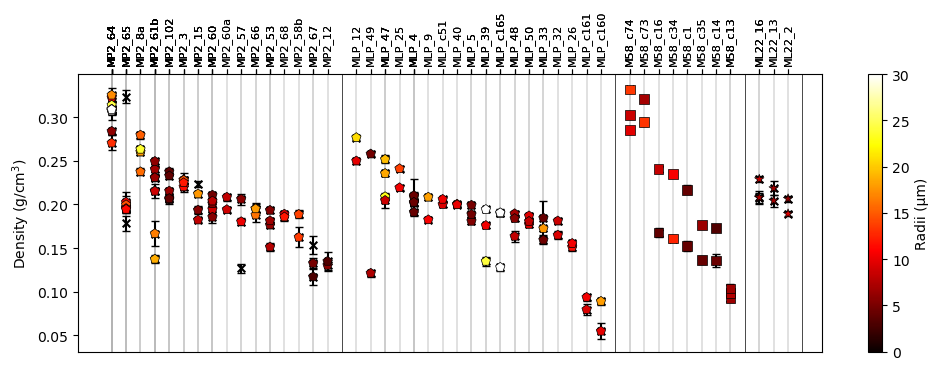

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

erup_symbol=['p', 'p', 's', '*']

# Assuming df_FI_ML is already defined

# Extract the characters before the second underscore
df_FI_ML['crystal'] = df_FI_ML['Fluid inclusion Name'].apply(lambda x: '_'.join(x.split('_')[:2]))
eruptions = [1852, 1868, 1950, 2022]

fig, ax1 = plt.subplots(1, 1, figsize=(12, 3.6))

# Loop through each eruption year
x_offset = 0  # To ensure each eruption starts at a new section along the x-axis

xticks = []
xtick_labels = []


for eruption_index, eruption_year in enumerate(eruptions):
    df = df_FI_ML.loc[df_FI_ML['eruption'] == eruption_year]
    
    # Filter out groups with only one row
    group_counts = df['crystal'].value_counts()
    filtered_df = df[df['crystal'].isin(group_counts[group_counts > 1].index)]

    # Calculate range for each group and sort groups by max value
    group_ranges = filtered_df.groupby('crystal')['Density g/cm3'].apply(lambda x: x.max())
    sorted_groups = group_ranges.sort_values(ascending=False).index

    # Plot
    for i, group in enumerate(sorted_groups):
        group_data = filtered_df[filtered_df['crystal'] == group]
        x = np.full(group_data.shape[0], x_offset + i + 1)  # Equally spaced x positions within this eruption section
        y = group_data['Density g/cm3']
        yerr = group_data['σ Density g/cm3']
        
        ax1.errorbar(x, y, yerr=yerr, fmt=erup_symbol[eruption_index], color=erup_color[eruption_index], ms=0,
                     label=f'{eruption_year}' if i == 0 else "", alpha=1, capsize=3, mec='k', ecolor='k')
        
        ax1.scatter(x, y, s=30, marker='x', edgecolors='k', c='k', zorder=100)
        
        s = ax1.scatter(x, y, marker=erup_symbol[eruption_index], s=50, edgecolors='k', linewidths=0.5,
                        c=group_data['Av_radi'], cmap='hot', vmin=0, vmax=30, zorder=100)
        
        xticks.extend(x)
        xtick_labels.extend([group] * len(x))
    
    # Add a vertical line to separate different eruptions
    x_offset += len(sorted_groups) + 1
    ax1.axvline(x=x_offset, color='black', linestyle='-', lw=0.5)

#plt.xlabel('Crystal')
fig.colorbar(s, ax=ax1, label='Radii (μm)')
plt.ylabel('Density (g/cm$^3$)')

# Remove the title
# plt.title('Density by Group and Eruption Year')

plt.grid(axis='x', linestyle='-', linewidth=0.3)

# Move x-ticks to the top
ax1.xaxis.tick_top()
ax1.set_xticks(xticks)
ax1.set_xticklabels(xtick_labels, rotation=90, fontsize=8)
ax1.xaxis.set_ticks_position('top')  # Remove ticks from the bottom

fig.savefig('allEruptions_differences.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


## Figure 6 panel a-b

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\591768266.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_mapping[label] for label in filtered_df_violin['Unique_Crystal'].unique()], rotation=90)
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\591768266.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_violin['Sample_Position'] = filtered_df_violin['Sample'].astype('category').cat.codes


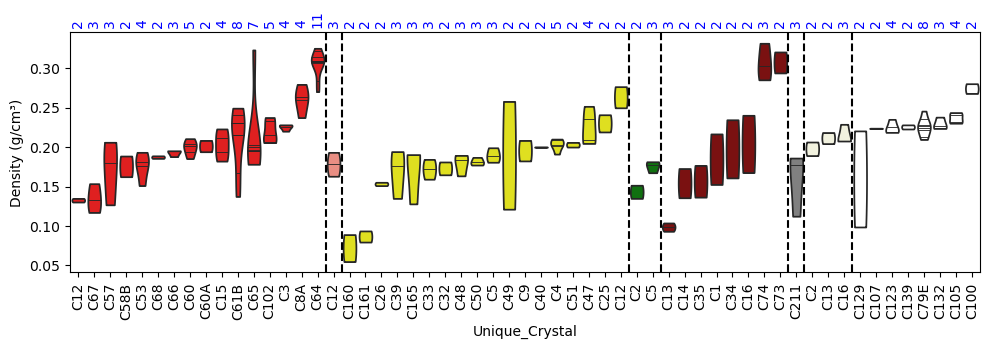

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data preparation
df_violin = df_FI_ML.copy()

df_violin['Sample'] = df_violin['eruption']
df_violin['Unique_Crystal'] = df_violin['crystal']
df_violin['Density'] = df_FI_ML['Density g/cm3']
df_violin['Unique_Crystal'] = df_violin['Unique_Crystal'].str.upper()

# Extract Crystal Number and prepare shorter labels
df_violin['Crystal_Number'] = df_violin['Unique_Crystal'].str.split('_').str[-1]
df_violin['Crystal_Number'] = df_violin['Crystal_Number'].apply(
    lambda x: f'C{x}' if not x.startswith('C') else x
)

# Sort and process data
df_violin = df_violin.sort_values(by=['eruption'])
average_density = df_violin.groupby('Unique_Crystal')['Density'].mean().rename('Avg_Density')
df_violin = df_violin.merge(average_density, on='Unique_Crystal', how='left')
df_violin = df_violin.sort_values(by=['eruption', 'Avg_Density'])
filtered_df_violin = df_violin[df_violin.groupby('Unique_Crystal')['Unique_Crystal'].transform('size') > 1]

# Set custom colors for the hue
custom_colors = ['red', 'salmon', 'yellow', 'green', 'darkred', 'grey', 'beige', 'white']

custom_colors = sns.color_palette(custom_colors, as_cmap=False, n_colors=len(custom_colors))
custom_colors = [(r, g, b, 0.1) for r, g, b in custom_colors]

# Set figure size and create violin plot
plt.figure(figsize=(10, 3.6))
ax = sns.violinplot(
    x='Unique_Crystal',  # Grouping remains by 'Unique_Crystal'
    y='Density', 
    data=filtered_df_violin, 
    inner='stick', 
    density_norm='width', 
    cut=0, 
    hue='eruption', 
    palette=custom_colors
)
ax.legend_.remove()

# Map the shorter labels to the x-axis
custom_labels = filtered_df_violin[['Unique_Crystal', 'Crystal_Number']].drop_duplicates()
label_mapping = dict(zip(custom_labels['Unique_Crystal'], custom_labels['Crystal_Number']))
ax.set_xticklabels([label_mapping[label] for label in filtered_df_violin['Unique_Crystal'].unique()], rotation=90)

# Annotate the number of measurements
x_labels = filtered_df_violin['Unique_Crystal'].unique()
crystal_counts = filtered_df_violin['Unique_Crystal'].value_counts()
for i, crystal in enumerate(x_labels):
    count = crystal_counts[crystal]
    ax.text(i, max(filtered_df_violin['Density']) + 0.02, f'{count}', 
            ha='center', va='bottom', fontsize=10, color='blue', rotation=90)

# Draw vertical lines at sample boundaries
filtered_df_violin['Sample_Position'] = filtered_df_violin['Sample'].astype('category').cat.codes
unique_samples = filtered_df_violin[['Unique_Crystal', 'Sample']].drop_duplicates().reset_index(drop=True)
sample_boundaries = unique_samples['Sample'].ne(unique_samples['Sample'].shift()).cumsum()
boundary_indices = unique_samples.groupby(sample_boundaries).size().cumsum() - 1
for pos in boundary_indices[:-1]:
    plt.axvline(pos + 0.5, color='black', linestyle='--', linewidth=1.5)

# Customize plot appearance

plt.ylabel('Density (g/cm³)')
plt.tight_layout()



# Save and display the plot
plt.savefig('Violin_custom_colors.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 6 - Panel C

Percentage Variation Components for Each Sample:
        Within Crystal  Between Crystal
Sample                                 
1852          9.017136        23.749082
1855          8.499491        53.834120
1868         11.412796        23.173226
1949          6.166929        12.830408
1950         16.286638        34.648841
1984         25.426050        15.652926
2022          5.495965        10.846836
7360          9.188028        17.114346


C:\Users\penny\AppData\Local\Temp\ipykernel_39952\1053692395.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  variation_results = df_violin.groupby('Sample').apply(


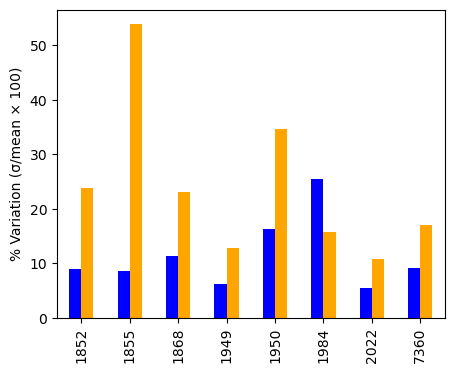

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a function to compute % variation (std/mean) for within and between groups
def calculate_variation_components(sample_data):
    # Calculate mean and standard deviation within each Unique_Crystal
    group_stats = sample_data.groupby('Unique_Crystal')['Density'].agg(['mean', 'std'])

    # Calculate % variation (std/mean) within each crystal
    within_crystal_variation = (group_stats['std'] / group_stats['mean']) * 100

    # Calculate % variation (std/mean) between crystals
    crystal_means = group_stats['mean']
    between_crystal_std = crystal_means.std()
    between_crystal_mean = crystal_means.mean()
    between_crystal_variation = (between_crystal_std / between_crystal_mean) * 100

    # Calculate the overall % variation within crystals (average % variation)
    overall_within_variation = within_crystal_variation.mean()

    return overall_within_variation, between_crystal_variation

# Group data by Sample and apply the function to each group
variation_results = df_violin.groupby('Sample').apply(
    lambda x: pd.Series(calculate_variation_components(x), index=['Within Crystal', 'Between Crystal'])
)

# Display the results
print("Percentage Variation Components for Each Sample:")
print(variation_results)

# Adjustable plot size
plt.figure(figsize=(5, 4))  # Set the figure size
variation_results.plot(kind='bar', legend=False, color=['blue', 'orange'], ax=plt.gca())  # Use current axes for tighter control
plt.ylabel('% Variation (σ/mean × 100)')
plt.xticks(rotation=90)
plt.xlabel('')
plt.savefig('VariationComparison_ML.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


## Figure 6 Panel b

In [93]:
df_Z=pd.read_excel('Online_Resource_1.xlsx', sheet_name='ZanonDataForPlotting')

df=df_Z.loc[df_Z['ThL']<30.97].reset_index(drop=True)
df['Unique_Crystal'] = df['Sample'] + "_" + df['Crystal']

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2860536991.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_tick_labels, rotation=90)
C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2860536991.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_violin['Sample_Position'] = filtered_df_violin['Sample'].astype('category').cat.codes


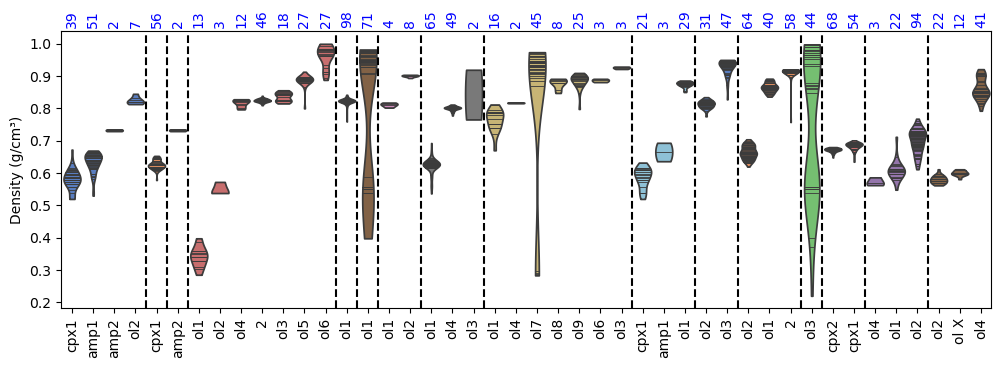

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

df_violin = df.copy()

# List of eruptions
eruptions = ['Can15', 'Can22', 'Can37', 'Can39', 'Can43', 'Can45', 'Can46',
             'Can52', 'Can128', 'Can214', 'Can312', 'Can340', 'Can370', 
             'LPA16', 'LPA17', 'LPA18']

# Extract eruption value by checking which entry matches the prefix
df_violin['eruption'] = df_violin['Sample'].apply(
    lambda x: ''.join(filter(str.isdigit, x.split('_')[0])) if x.split('_')[0] in eruptions else None
)

# Calculate the average density for each Unique_Crystal
average_density = df_violin.groupby('Unique_Crystal')['Density'].mean().rename('Avg_Density')
df_violin = df_violin.merge(average_density, on='Unique_Crystal', how='left')

# Sort by eruption first, then by average density
df_violin = df_violin.sort_values(by=['eruption', 'Avg_Density'])

# Filter to include only crystals with more than one measurement
filtered_df_violin = df_violin[df_violin.groupby('Unique_Crystal')['Unique_Crystal'].transform('size') > 1]

# Set figure size
plt.figure(figsize=(12, 3.6))  # Updated figure size

# Create a violin plot of Density by Unique_Crystal, colored by eruption
ax = sns.violinplot(
    x='Unique_Crystal', 
    y='Density', 
    data=filtered_df_violin,  # Use the filtered DataFrame
    inner='stick', 
    density_norm='width', 
    cut=0, 
    hue='eruption', 
    palette='muted'
)

# Generate modified labels for x-axis
unique_crystals = filtered_df_violin['Unique_Crystal'].unique()
modified_labels = {
    crystal: (
        crystal.rsplit('_', 1)[-1]  # Take text after the last underscore
        .replace('olivine', 'ol')   # Replace 'Olivine' with 'ol'
        .replace('oliv', 'ol')      # Replace 'oliv' with 'ol'
        .replace('Oliv', 'ol')      # Replace 'Oliv' with 'ol'
        .replace('Amp', 'amp')      # Replace 'Amp' with 'amp'
        .replace('Amph', 'amp') 
        .replace('amph', 'amp')    # Replace 'Amph' with 'amp'
        .replace('Cpx', 'cpx')      # Replace 'Cpx' with 'cpx'
        .replace('Ol', 'ol')        # Replace 'Ol' with 'ol'
        .replace('oline', 'ol')
        .replace('olin', 'ol')
                  # Replace 'Oline' with 'ol'
    )
    for crystal in unique_crystals
}

# Apply modified labels to the x-axis
x_tick_texts = [tick.get_text() for tick in ax.get_xticklabels()]
x_tick_labels = [modified_labels[label] if label in modified_labels else label for label in x_tick_texts]
ax.set_xticklabels(x_tick_labels, rotation=90)

# Remove the x-axis label
plt.xlabel(None)  # This removes the x-axis label

# Remove the legend
ax.legend_.remove()

# Get the unique Sample groups and their positions in the plot
filtered_df_violin['Sample_Position'] = filtered_df_violin['Sample'].astype('category').cat.codes
unique_samples = filtered_df_violin[['Unique_Crystal', 'Sample']].drop_duplicates().reset_index(drop=True)

# Identify the boundary positions for each Sample
sample_boundaries = unique_samples['Sample'].ne(unique_samples['Sample'].shift()).cumsum()
boundary_indices = unique_samples.groupby(sample_boundaries).size().cumsum() - 1

for pos in boundary_indices[:-1]:  # Skip the last index to avoid adding a line at the very end
    plt.axvline(pos + 0.5, color='black', linestyle='--', linewidth=1.5)

# Customize the plot
plt.ylabel('Density (g/cm³)')

# Annotate the number of measurements for each crystal
x_labels = filtered_df_violin['Unique_Crystal'].unique()
crystal_counts = filtered_df_violin['Unique_Crystal'].value_counts()
for i, crystal in enumerate(x_labels):
    count = crystal_counts[crystal]
    ax.text(i, max(filtered_df_violin['Density']) + 0.05, f'{count}', 
            ha='center', va='bottom', fontsize=10, color='blue', rotation=90)

# Save the figure
plt.savefig('Violin_sorted_by_eruption_and_density.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 6 - Panel d

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2477661161.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  variation_results = df_violin.groupby('Sample').apply(


Percentage Variation Components for Each Sample:
        Within Crystal  Between Crystal
Sample                                 
Can128        3.094260        15.467370
Can15         2.245376              NaN
LPA16         0.512979              NaN
LPA17         3.191698        29.372409
LPA18         1.122525              NaN
Can214       30.949881         6.956044
Can22         0.574675         7.371889
Can312        5.859408        14.377044
Can340        5.841437         6.059752
Can37         3.587832        21.090478
Can370        2.110809         9.358115
Can39         2.367438        16.224589
Can43        30.245734              NaN
Can45         1.358623         1.235961
Can46         4.158130        10.357682
Can52         2.427198        23.067317


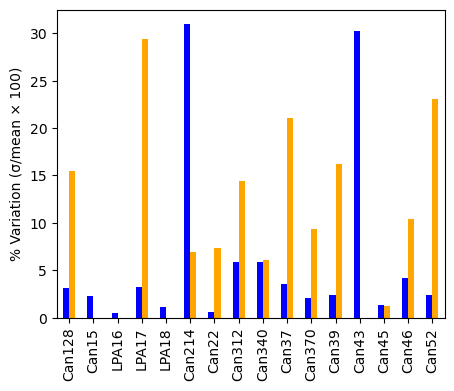

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a function to compute % variation (std/mean) for within and between groups
def calculate_variation_components(sample_data):
    # Calculate mean and standard deviation within each Unique_Crystal
    group_stats = sample_data.groupby('Unique_Crystal')['Density'].agg(['mean', 'std'])

    # Calculate % variation (std/mean) within each crystal
    within_crystal_variation = (group_stats['std'] / group_stats['mean']) * 100

    # Calculate % variation (std/mean) between crystals
    crystal_means = group_stats['mean']
    between_crystal_std = crystal_means.std()
    between_crystal_mean = crystal_means.mean()
    between_crystal_variation = (between_crystal_std / between_crystal_mean) * 100

    # Calculate the overall % variation within crystals (average % variation)
    overall_within_variation = within_crystal_variation.mean()

    return overall_within_variation, between_crystal_variation

# Group data by Sample and apply the function to each group
variation_results = df_violin.groupby('Sample').apply(
    lambda x: pd.Series(calculate_variation_components(x), index=['Within Crystal', 'Between Crystal'])
)

# Define the custom order for samples
custom_order = ['Can128', 'Can15', 'LPA16', 'LPA17', 'LPA18', 'Can214', 'Can22', 
                'Can312', 'Can340', 'Can37', 'Can370', 'Can39', 'Can43', 'Can45', 
                'Can46', 'Can52']

# Reindex the results to match the custom order
variation_results = variation_results.reindex(custom_order)

# Display the reordered results
print("Percentage Variation Components for Each Sample:")
print(variation_results)

# Adjustable plot size
plt.figure(figsize=(5, 4))  # Set the figure size
variation_results.plot(kind='bar', legend=False, color=['blue', 'orange'], ax=plt.gca())  # Use current axes for tighter control
plt.ylabel('% Variation (σ/mean × 100)')
plt.xticks(rotation=90)
plt.xlabel('')
plt.savefig('VariationComparison_CustomOrder_LaPalma.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


## SO2 degassing figure 5 a-d

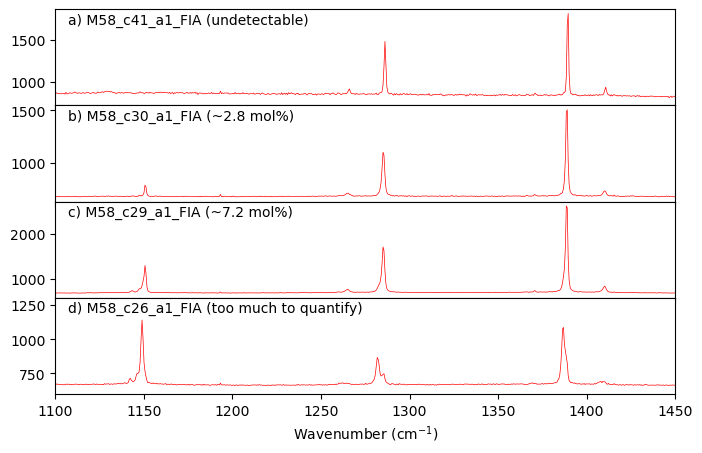

In [96]:


data0=pd.read_excel('Online_Resource_1.xlsx', sheet_name='27 M58_c41_a1_FIA Spectra')

data1=pd.read_excel('Online_Resource_1.xlsx', sheet_name='09 M58_c30_a1_FIA Spectra')

data2=pd.read_excel('Online_Resource_1.xlsx', sheet_name='07 M58_c29_a1_FIA Spectra')

data3=pd.read_excel('Online_Resource_1.xlsx', sheet_name='03 M58_c26_a1_FIA_crazySO2 Spec')



fig, (ax0, ax1, ax2, ax3) = plt.subplots(4, 1, figsize=(8,5),  sharex=True)
fig.subplots_adjust(hspace=0) 

ax0.plot(data0['Wavenumber'], data0['Intensity'], '-r', lw=0.5)
ax0.annotate("a) M58_c41_a1_FIA (undetectable)", xy=(0.02, 0.85), xycoords="axes fraction", fontsize=10)

ax1.plot(data1['Wavenumber'], data1['Intensity'], '-r', lw=0.5)
ax1.annotate("b) M58_c30_a1_FIA (~2.8 mol%)", xy=(0.02, 0.85), xycoords="axes fraction", fontsize=10)

ax2.plot(data2['Wavenumber'], data2['Intensity'], '-r', lw=0.5)
ax2.annotate("c) M58_c29_a1_FIA (~7.2 mol%)", xy=(0.02, 0.85), xycoords="axes fraction", fontsize=10)

ax3.plot(data3['Wavenumber'], data3['Intensity'], '-r', lw=0.5)
ax3.set_ylim([600, 1300])
ax3.annotate("d) M58_c26_a1_FIA (too much to quantify)", xy=(0.02, 0.85), xycoords="axes fraction", fontsize=10)
ax1.set_xlim([1100, 1450])
ax3.set_xlabel('Wavenumber (cm$^{-1}$)')
#ax2.set_ylabel('Intensity (counts)')
fig.savefig('SO2_Spectra.png', dpi=300, transparent=True)

## SO2 degassing figure 5e

In [97]:
## Lets load in the SulfurX degassing models

df_43_03=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.10')

df_43=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.13')

df_58=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.16')

df_62=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.20')

df_64=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.23')

df_66=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.28')

df_68=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.34')

df_70=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.42')

df_72=pd.read_excel('Online Resource 2.xlsx', sheet_name='S6+_ST=0.50')

## And decompress
Dcomp=pd.read_excel('Online Resource 2.xlsx', sheet_name='Dcompress')


## Figure 5 part e

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\2647466433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FI_ML['SO2_Burke_table_pref']=df_FI_ML['SO2_Burke_table_pref'].fillna(0)


0.1008577395506588
0.1342013971744866
0.1589879380311985
0.1957388591617032
0.2289080416558583
0.2763698187334731
0.3401508381339605
0.4175352240518279
0.5046221685989225


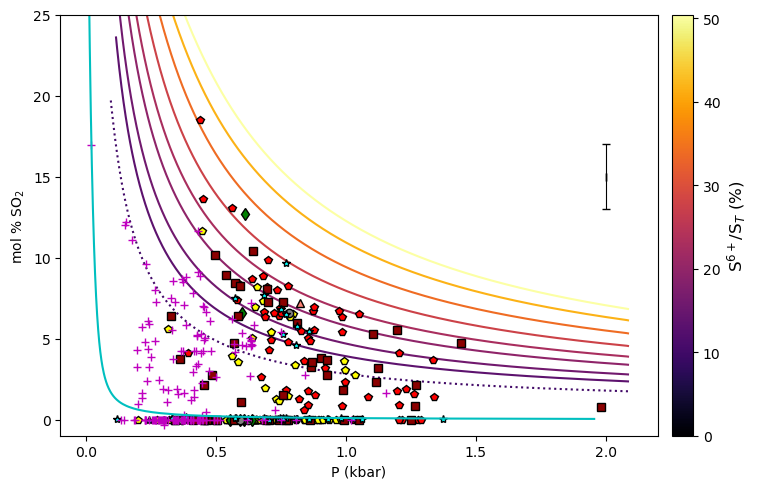

In [98]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
df_FI_ML['SO2_Burke_table_pref']=df_FI_ML['SO2_Burke_table_pref'].fillna(0)
fig, ((ax1)) = plt.subplots(1, 1, figsize=(8, 5), sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

dfs = [df_43_03, df_43, df_58, df_62, df_64, df_66, df_68, df_70, df_72]
#dfs = [df_43_03, df_55, df_638, df_688, df_723, df_75]

# Normalize the `S6+/ST` values for colormap mapping
s6_st_values = [100*df['S6+/ST'].iloc[1] for df in dfs]
norm = mcolors.Normalize(vmin=0, vmax=max(s6_st_values))
cmap = cm.inferno

# Plot each DataFrame with color mapped to `S6+/ST`
i=0
for df in dfs:
    print(df['S6+/ST'].iloc[1])
    color = cmap(norm(100*df['S6+/ST'].iloc[1]))
    if i==0:
        ax1.plot(
        df['pressure'].iloc[2:960] / 100,
        100*df['XSO2_fluid'].iloc[2:960],
        ':',
        color=color,
        label=100*np.round(df['S6+/ST'].iloc[1], 1)
    ) 
    else:  
        ax1.plot(
            df['pressure'].iloc[2:950] / 100,
            100*df['XSO2_fluid'].iloc[2:950],
            '-',
            color=color,
            label=np.round(100*df['S6+/ST'].iloc[1], 1)
        )

    i=i+1
#ax1.legend()

# Adding eruption-specific points
# eruption = [8870, 1852, 1855, 1868, 1949, 1950, 1984, 2022]
# erup_color = ['white', 'red', 'salmon', 'yellow', 'green', 'darkred', 'grey', 'cyan']
# erup_symbol = ['o', 'p', '^', 'p', 'd', 's', 'o', '*']

eruption=[8870, 1852, 1855, 1868,  1949, 1950, 1984, 2022]
erup_color=['white', 'red', 'salmon', 'yellow', 'green', 'darkred',  'grey', 'cyan']
erup_symbol=['o', 'p', '^', 'p', 'd', 's', 'o', '*']


for erup, col, sym in zip(eruption, erup_color, erup_symbol):
    px = df_FI_ML['CaO'] > 0.4
    df = df_FI_ML.loc[~px]
    x1 = df['P(kbar)_HC'].loc[df['eruption'] == erup]
    y1 = 100*df['SO2_Burke_table_pref'].loc[df['eruption'] == erup]
    ax1.plot(x1, y1, sym, mfc=col, mec='k', label=erup)

    df_px = df_FI_ML.loc[px]
    x2 = df_px['P(kbar)_HC'].loc[df_px['eruption'] == erup]
    y2 = 100*df_px['SO2_Burke_table_pref'].loc[df_px['eruption'] == erup]

df_22 = df_22.copy()  # If needed
ax1.plot(df_22['SingleFI_P_kbar'], df_22['SO2_Burke_table_pref'], '*k', mfc='cyan')

SO2_combo = pd.concat([
    100*df_22['SO2_Burke_table_pref'],
    100*df_FI_ML['SO2_Burke_table_pref']
], ignore_index=True)

ax1.set_xlabel('P (kbar)')
ax1.set_ylabel('mol % SO$_2$')

ax1.set_ylim([-1, 25])
ax1.plot(df_kil_d['P_kbar'].fillna(0), 100*df_kil_d['SO2_Burke_table_pref'].fillna(0), '+m')

# Add a colorbar for the `S6+/ST` values
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Placeholder array for the colorbar
cbar = fig.colorbar(sm, ax=ax1, orientation='vertical', pad=0.02)
cbar.set_label('S$^{6+}$/S$_{T}$ (%)', fontsize=12)
fig.tight_layout()


plt.plot(Dcomp['P(bar)']/1000, 100*Dcomp['SO2_mol_perc'], '-c')


# plt.plot(
#         df_50_open['pressure'].iloc[1:990] / 100,
#         100*df_50_open['XSO2_fluid'].iloc[1:990] , '-b', label='open')
ax1.set_xlim([-0.1, 2.2])

## add an error bar
ax1.errorbar(x=2, y=15, xerr=0, yerr=2,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=0, mec='k', capsize=3)
# Save the figure
fig.savefig('SO2.png', dpi=300, transparent=True)

plt.show()


## Figure 9 - EBSD things

In [131]:
# Lets read it in and see how consistent our data is - 
# Note - on May 20th, went through manually matching up EBSD with FI, and refit a variety of data, so dont want to remerge this all again without taking note of that. 
# merge in new data after here
combined_df=pd.read_excel('Online_Resource_1.xlsx', sheet_name='EBSD_data_slip_system_ML')

slip_sys_all = combined_df.loc[:, 'len1':'len20'].values.flatten()
slip_sys_all = slip_sys_all[(~np.isnan(slip_sys_all))&(slip_sys_all<600)&(slip_sys_all>10)]

## Segment by eruption
# Initialize eruption column
combined_df['eruption'] = 'z'

# Assign eruption values based on substrings in 'Filename', safely handling NaNs
combined_df.loc[combined_df['Filename'].str.contains('MP2', na=False), 'eruption'] = 1852
combined_df.loc[combined_df['Filename'].str.contains('MLP', na=False), 'eruption'] = 1868
combined_df.loc[combined_df['Filename'].str.contains('ori', na=False), 'eruption'] = 2022
combined_df.loc[combined_df['Filename'].str.contains('ML22', na=False), 'eruption'] = 2022
combined_df.loc[combined_df['Filename'].str.contains('M58', na=False), 'eruption'] = 1950
combined_df.loc[combined_df['Filename'].str.contains('79e', na=False), 'eruption'] = 8870

combined_df_kil=pd.read_excel('Online_Resource_1.xlsx', sheet_name='EBSD_data_slip_system_Kil')

slip_sys_all_kil = combined_df_kil.loc[:, 'len1':'len20'].values.flatten()
slip_sys_all_kil = slip_sys_all_kil[(~np.isnan(slip_sys_all_kil))&(slip_sys_all_kil<600)&(slip_sys_all_kil>10)]



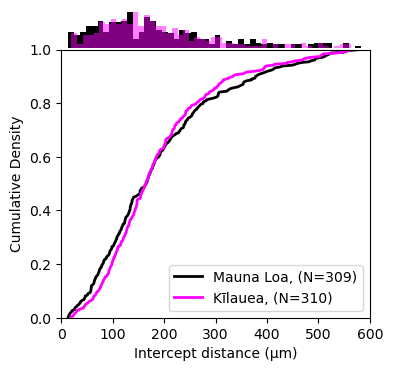

In [132]:
fig, ((ax_hist_top, deadspace), (ax2, ax2_hist)) = plt.subplots(
    2, 2, figsize=(4, 4), sharex=True,
    gridspec_kw={'width_ratios': [5.6, 0], 'height_ratios': [0.5, 3.5], 'wspace': 0.01, 'hspace': 0.01}
)


ax_hist_top.axes.get_xaxis().set_visible(False)
ax_hist_top.axes.get_yaxis().set_visible(False)
ax_hist_top.axis("off")

ax2_hist.axes.get_xaxis().set_visible(False)
ax2_hist.axes.get_yaxis().set_visible(False)
ax2_hist.axis("off")

deadspace.axes.get_xaxis().set_visible(False)
deadspace.axes.get_yaxis().set_visible(False)
deadspace.axis("off")

# Sort the data
slip_sys_all_sorted = np.sort(slip_sys_all)

slip_sys_all_kil_sorted = np.sort(slip_sys_all_kil)

# Calculate the cumulative distribution
cdf_slip_sys_all = np.arange(1, len(slip_sys_all_sorted)+1) / len(slip_sys_all_sorted)

cdf_slip_sys_all_kil = np.arange(1, len(slip_sys_all_kil_sorted)+1) / len(slip_sys_all_kil_sorted)

# Plot the CDFs
ax2.plot(slip_sys_all_sorted, cdf_slip_sys_all, lw=2, color='black', label=f"Mauna Loa, (N={len(cdf_slip_sys_all)})")
ax2.plot(slip_sys_all_kil_sorted, cdf_slip_sys_all_kil,  lw=2, color='magenta', label=f"Kīlauea, (N={len(cdf_slip_sys_all_kil)})")

ax_hist_top.hist(slip_sys_all_sorted, label='slip_sys_all', lw=2, color='black', bins=50);
ax_hist_top.hist(slip_sys_all_kil_sorted,  label='slip_sys_all_kil', lw=2, color='magenta', bins=50, alpha=0.5);
ax2.set_xlabel('Intercept distance (μm)')
ax2.set_ylabel('Cumulative Density')
ax2.set_xlim([0, 600])
ax2.legend()
ax2.set_ylim([0, 1])
fig.savefig('LinearInterceptDistances.png', dpi=200, transparent=True, bbox_inches='tight')

In [133]:
combined_df_kil['Perc Tilt']=100*(combined_df_kil['Tilt length']/(combined_df_kil['Tilt length']+combined_df_kil['Twist length']))
combined_df_kil['Perc Twist']=100*(combined_df_kil['Twist length']/(combined_df_kil['Tilt length']+combined_df_kil['Twist length']))
combined_df['Perc Tilt']=100*(combined_df['Tilt length']/(combined_df['Tilt length']+combined_df['Twist length']))
combined_df['Perc Twist']=100*(combined_df['Twist length']/(combined_df['Tilt length']+combined_df['Twist length']))

In [134]:
# Bigger grains contribute more
Alength_sum_kil=sum(combined_df_kil['a length'])
Dlength_sum_kil=sum(combined_df_kil['D length'])
Elength_sum_kil=sum(combined_df_kil['E length'])
Blength_sum_kil=sum(combined_df_kil['B length'])
Clength_sum_kil=sum(combined_df_kil['C length'])
Class_tot_all_kil=Alength_sum_kil+ Elength_sum_kil+ Dlength_sum_kil+Blength_sum_kil+ Clength_sum_kil
TwistTilt_tot_all_kil=sum(combined_df_kil['Tilt length'])+sum(combined_df_kil['Twist length'])
Alength_prop_kil=Alength_sum_kil/Class_tot_all_kil
Blength_prop_kil=Blength_sum_kil/Class_tot_all_kil
Clength_prop_kil=Clength_sum_kil/Class_tot_all_kil
Dlength_prop_kil=Dlength_sum_kil/Class_tot_all_kil
Elength_prop_kil=Elength_sum_kil/Class_tot_all_kil
Twistlength_prop_kil=sum(combined_df_kil['Twist length'])/TwistTilt_tot_all_kil
Tiltlength_prop_kil=sum(combined_df_kil['Tilt length'])/TwistTilt_tot_all_kil



# Each grain contributes equally
Class_totgrain_kil=combined_df_kil['a length']+combined_df_kil['B length']+combined_df_kil['C length']+combined_df_kil['D length']+combined_df_kil['E length']
TwistTilt_totgrain_kil=combined_df_kil['Tilt length']+combined_df_kil['Twist length']
Alengthgrain_kil=np.nanmean(combined_df_kil['a length']/Class_totgrain_kil)
Dlengthgrain_kil=np.nanmean(combined_df_kil['D length']/Class_totgrain_kil)
Elengthgrain_kil=np.nanmean(combined_df_kil['E length']/Class_totgrain_kil)
Blengthgrain_kil=np.nanmean(combined_df_kil['B length']/Class_totgrain_kil)
Clengthgrain_kil=np.nanmean(combined_df_kil['C length']/Class_totgrain_kil)
Twistlengthgrain_kil=np.nanmean(combined_df_kil['Twist length']/TwistTilt_totgrain_kil)
Tiltlengthgrain_kil=np.nanmean(combined_df_kil['Tilt length']/TwistTilt_totgrain_kil)


# MAUNA LOA SAME 

# Bigger grains contribute more
Alength_sum=sum(combined_df['a length'])
Dlength_sum=sum(combined_df['D length'])
Elength_sum=sum(combined_df['E length'])
Blength_sum=sum(combined_df['B length'])
Clength_sum=sum(combined_df['C length'])
Class_tot_all=Alength_sum+ Elength_sum+ Dlength_sum+Blength_sum+ Clength_sum
TwistTilt_tot_all=sum(combined_df['Tilt length'])+sum(combined_df['Twist length'])
Alength_prop=Alength_sum/Class_tot_all
Blength_prop=Blength_sum/Class_tot_all
Clength_prop=Clength_sum/Class_tot_all
Dlength_prop=Dlength_sum/Class_tot_all
Elength_prop=Elength_sum/Class_tot_all
Twistlength_prop=sum(combined_df['Twist length'])/TwistTilt_tot_all
Tiltlength_prop=sum(combined_df['Tilt length'])/TwistTilt_tot_all





# Each grain contributes equally
Class_totgrain=combined_df['a length']+combined_df['B length']+combined_df['C length']+combined_df['D length']+combined_df['E length']
TwistTilt_totgrain=combined_df['Tilt length']+combined_df['Twist length']
Alengthgrain=np.nanmean(combined_df['a length']/Class_totgrain)
Dlengthgrain=np.nanmean(combined_df['D length']/Class_totgrain)
Elengthgrain=np.nanmean(combined_df['E length']/Class_totgrain)
Blengthgrain=np.nanmean(combined_df['B length']/Class_totgrain)
Clengthgrain=np.nanmean(combined_df['C length']/Class_totgrain)
Twistlengthgrain=np.nanmean(combined_df['Twist length']/TwistTilt_totgrain)
Tiltlengthgrain=np.nanmean(combined_df['Tilt length']/TwistTilt_totgrain)

In [135]:
# Doing this on a grain basis 
datagrain_ML = {
    'Category': ['Tilt', 'Twist', 'A', 'D', 'E', 'B', 'C'],
    'Length Sum': [100*Tiltlengthgrain, 100*Twistlengthgrain, 100*Alengthgrain,  100*Dlengthgrain,  100*Elengthgrain, 100*Blengthgrain, 100*Clengthgrain]  # Example values for Alength_sum to Elength_sum
}
length_dfgrain_ML = pd.DataFrame(datagrain_ML)



datagrain_kil = {
    'Category': ['Tilt', 'Twist', 'A', 'D', 'E', 'B', 'C'],
    'Length Sum': [100*Tiltlengthgrain_kil, 100*Twistlengthgrain_kil, 100*Alengthgrain_kil,  100*Dlengthgrain_kil,  100*Elengthgrain_kil, 100*Blengthgrain_kil, 100*Clengthgrain_kil]  # Example values for Alength_sum_kil to Elength_sum_kil
}
length_dfgrain_kil = pd.DataFrame(datagrain_kil)


data_tot_kil = {
    'Category': ['Tilt', 'Twist', 'A', 'D', 'E', 'B', 'C'],
    'Length Sum': [100*Tiltlength_prop_kil, 100*Twistlength_prop_kil, 100*Alength_prop_kil,  100*Dlength_prop_kil,  100*Elength_prop_kil, 
                   100*Blength_prop_kil, 100*Clength_prop_kil]  # Example values for Alength_sum_kil to Elength_sum_kil
}
length_df_tot_kil = pd.DataFrame(data_tot_kil)

data_tot_ML = {
    'Category': ['Tilt', 'Twist', 'A', 'D', 'E', 'B', 'C'],
    'Length Sum': [100*Tiltlength_prop, 100*Twistlength_prop,100*Alength_prop,  100*Dlength_prop,  100*Elength_prop, 
                   100*Blength_prop, 100*Clength_prop]  # Example values for Alength_sum to Elength_sum
}
length_df_tot_ML = pd.DataFrame(data_tot_ML)




## Figure 9a

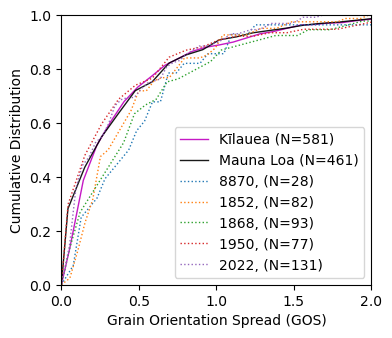

In [139]:
eruption_years = [8870,  1852,1868, 1950, 2022,]

plt.figure(figsize=(4, 3.5))

pixelcutoff=100

subset1 = combined_df_kil['GOS_x'].loc[(combined_df_kil['equivalentRadius (um)']>pixelcutoff)]
values1, base1 = np.histogram(subset1, bins=40)
cumulative1 = np.cumsum(values1)
base1 = np.append(0, base1)
cumulative1 = np.append(0, cumulative1)
plt.plot(base1[:-1], cumulative1 / cumulative1[-1], label=f'Kīlauea (N={len(subset1)})', color='m', linestyle='-', linewidth=1, alpha=0.9)


subset2 = combined_df['GOS_x'].loc[ (combined_df['equivalentRadius (um)']>pixelcutoff)]
values2, base2 = np.histogram(subset2, bins=40)
cumulative2 = np.cumsum(values2)
base2 = np.append(0, base2)
cumulative2 = np.append(0, cumulative2)
plt.plot(base2[:-1], cumulative2 / cumulative2[-1], label=f'Mauna Loa (N={len(subset2)})', color='k',linestyle='-', linewidth=1, alpha=0.9)

for year in eruption_years:
    subset3 = combined_df['GOS_x'].loc[(combined_df['eruption'] == year) & (combined_df['equivalentRadius (um)']>pixelcutoff)]
    values3, base3 = np.histogram(subset3, bins=40)
    cumulative3 = np.cumsum(values3)
    base3 = np.append(0, base3)
    cumulative3 = np.append(0, cumulative3)
    plt.plot(base3[:-1], cumulative3 / cumulative3[-1], label=f'{year}, (N={len(subset3)}) ', linestyle=':',linewidth=1)


plt.xlabel('Grain Orientation Spread (GOS)')
plt.ylabel('Cumulative Distribution')
plt.legend()

#plt.grid(True)

plt.xlim([0, 2])
plt.ylim([0, 1])
plt.savefig('GOS.png', dpi=200, transparent=True, bbox_inches='tight')

## Figure 9b

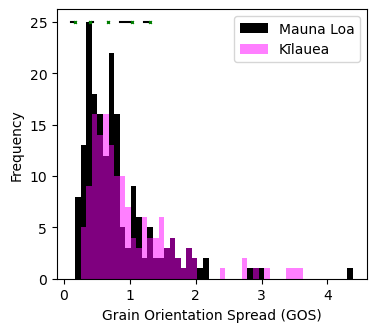

In [105]:
plt.figure(figsize=(4, 3.5))
pixelcutoff=100
ML_plot=combined_df['GOS_x'].loc[(combined_df['equivalentRadius (um)']>pixelcutoff) &  (combined_df['Deformed']=='Y')]
Kil_plot=combined_df_kil['GOS_x'].loc[(combined_df_kil['equivalentRadius (um)']>pixelcutoff)& (combined_df_kil['Deformed']=='Y')]
plt.plot([0.44, 0.4], [25, 25], '-k')
plt.plot([1.21, 1.31], [25, 25], '-k')
plt.plot([0.11, 0.17], [25, 25], '-k')
plt.plot([0.68, 0.67], [25, 25], '-k')
plt.plot([0.85, 1.03], [25, 25], '-k')
# Lets color the Kil one pink - It is written so its Berkeley on the LHS, and cambridge on the RHS
plt.plot([0.4], [25], 'xg', ms=2)
plt.plot([1.31], [ 25], 'xg', ms=2)
plt.plot([ 0.17], [ 25], 'xg', ms=2)
plt.plot([0.67], [ 25], 'xg', ms=2)
plt.plot([1.03], [25], 'xg', ms=2)

combined_data = pd.concat([ML_plot, Kil_plot])
bins = np.linspace(combined_data.min(), combined_data.max(), 51)  # 51 edges for 50 bin
plt.hist(ML_plot,bins=bins, fc='black', label='Mauna Loa');
plt.hist(Kil_plot,bins=bins, fc='magenta', alpha=0.5, label='Kīlauea');
plt.xlabel('Grain Orientation Spread (GOS)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('GOShistogram_Deformed.png', dpi=200, bbox_inches='tight', transparent=True)

## Figure 9c

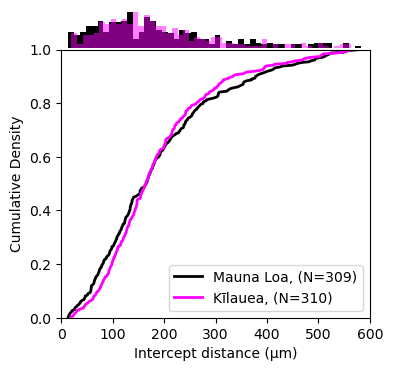

In [106]:
fig, ((ax_hist_top, deadspace), (ax2, ax2_hist)) = plt.subplots(
    2, 2, figsize=(4, 4), sharex=True,
    gridspec_kw={'width_ratios': [5.6, 0], 'height_ratios': [0.5, 3.5], 'wspace': 0.01, 'hspace': 0.01}
)


ax_hist_top.axes.get_xaxis().set_visible(False)
ax_hist_top.axes.get_yaxis().set_visible(False)
ax_hist_top.axis("off")

ax2_hist.axes.get_xaxis().set_visible(False)
ax2_hist.axes.get_yaxis().set_visible(False)
ax2_hist.axis("off")

deadspace.axes.get_xaxis().set_visible(False)
deadspace.axes.get_yaxis().set_visible(False)
deadspace.axis("off")

# Sort the data
slip_sys_all_sorted = np.sort(slip_sys_all)
slip_sys_all_kil_sorted = np.sort(slip_sys_all_kil)

# Calculate the cumulative distribution
cdf_slip_sys_all = np.arange(1, len(slip_sys_all_sorted)+1) / len(slip_sys_all_sorted)
cdf_slip_sys_all_kil = np.arange(1, len(slip_sys_all_kil_sorted)+1) / len(slip_sys_all_kil_sorted)

# Plot the CDFs
ax2.plot(slip_sys_all_sorted, cdf_slip_sys_all, lw=2, color='black', label=f"Mauna Loa, (N={len(cdf_slip_sys_all)})")
ax2.plot(slip_sys_all_kil_sorted, cdf_slip_sys_all_kil,  lw=2, color='magenta', label=f"Kīlauea, (N={len(cdf_slip_sys_all_kil)})")

ax_hist_top.hist(slip_sys_all_sorted, label='slip_sys_all', lw=2, color='black', bins=50);
ax_hist_top.hist(slip_sys_all_kil_sorted,  label='slip_sys_all_kil', lw=2, color='magenta', bins=50, alpha=0.5);
ax2.set_xlabel('Intercept distance (μm)')
ax2.set_ylabel('Cumulative Density')
ax2.set_xlim([0, 600])
ax2.legend()
ax2.set_ylim([0, 1])
fig.savefig('LinearInterceptDistances.png', dpi=200, transparent=True, bbox_inches='tight')

## Figure 9d

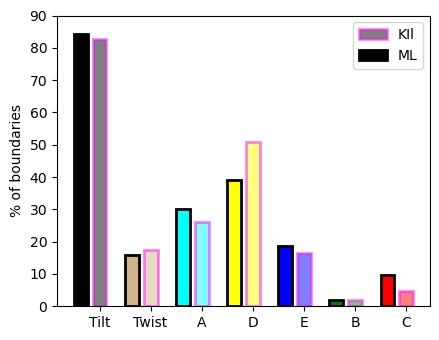

In [107]:
plt.rcParams.update({'font.size': 10})  # You can adjust this value as needed
# Set bar width
bar_width = 0.3
space_between_bars = 0.1  # Space between two bars of different datasets
space_between_categories = 0.4  # Space between different categories

# Create positions for the bars
positions_tot = []
positionsgrain_kil = []

# Create the positions dynamically
for i in range(len(length_df_tot_kil)):
    # Calculate position for total length bars
    positions_tot.append(i * (bar_width * 2 + space_between_bars + space_between_categories))
    # Calculate position for grain length bars, slightly to the left
    positionsgrain_kil.append(positions_tot[-1] - (bar_width + space_between_bars))

# Create the figure
plt.figure(figsize=(4.5, 3.5))

# Plot the total length bars
plt.bar(positions_tot, length_df_tot_kil['Length Sum'], width=bar_width, color=['black', 'tan', 'cyan', 'yellow', 'blue', 'green', 'red'], edgecolor='magenta',lw=2, alpha=0.5, label='KIl')

# Plot the grain length bars
plt.bar(positionsgrain_kil, length_df_tot_ML['Length Sum'], width=bar_width, color=['black',  'tan','cyan', 'yellow', 'blue', 'green', 'red'], ec='k', lw=2, label='ML')

# Add labels and title


plt.ylabel('% of boundaries')

# Set x-ticks to be the center of the total length bars
plt.xticks(positions_tot, length_dfgrain_kil['Category'])  
plt.legend()
plt.ylim([0, 90])
# Show the plot
plt.tight_layout()
plt.savefig('SlipSystem_compare_totalength.png', dpi=200, transparent=True)

C:\Users\penny\AppData\Local\Temp\ipykernel_39952\150005257.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


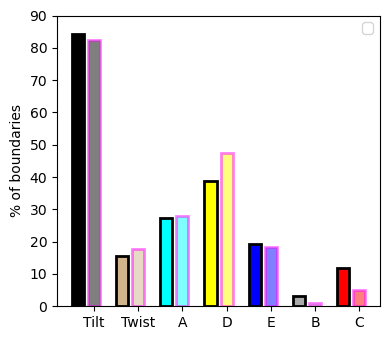

In [129]:
# Set bar width
bar_width = 0.3
space_between_bars = 0.1  # Space between two bars of different datasets
space_between_categories = 0.4  # Space between different categories

# Create positions for the bars
positions_tot = []
positionsgrain_kil = []

# Create the positions dynamically
for i in range(len(length_dfgrain_kil)):
    # Calculate position for total length bars
    positions_tot.append(i * (bar_width * 2 + space_between_bars + space_between_categories))
    # Calculate position for grain length bars, slightly to the left
    positionsgrain_kil.append(positions_tot[-1] - (bar_width + space_between_bars))

# Create the figure
plt.figure(figsize=(4, 3.5))

# Plot the total length bars
plt.bar(positions_tot, length_dfgrain_kil['Length Sum'], width=bar_width, color=['black', 'tan', 'cyan', 'yellow', 'blue', 'darkgrey', 'red'], edgecolor='magenta',lw=2, alpha=0.5)

# Plot the grain length bars
plt.bar(positionsgrain_kil, length_dfgrain_ML['Length Sum'], width=bar_width, color=['black',  'tan','cyan', 'yellow', 'blue', 'darkgrey', 'red'], 
        ec='k', lw=2)

# Add labels and title


plt.ylabel('% of boundaries')

# Set x-ticks to be the center of the total length bars
plt.xticks(positions_tot, length_dfgrain_kil['Category'])  
plt.legend()
plt.ylim([0, 90])
# Show the plot
plt.tight_layout()
plt.savefig('SlipSystem_compare_grain.png', dpi=200, transparent=True)

## Supplement 300 g scans

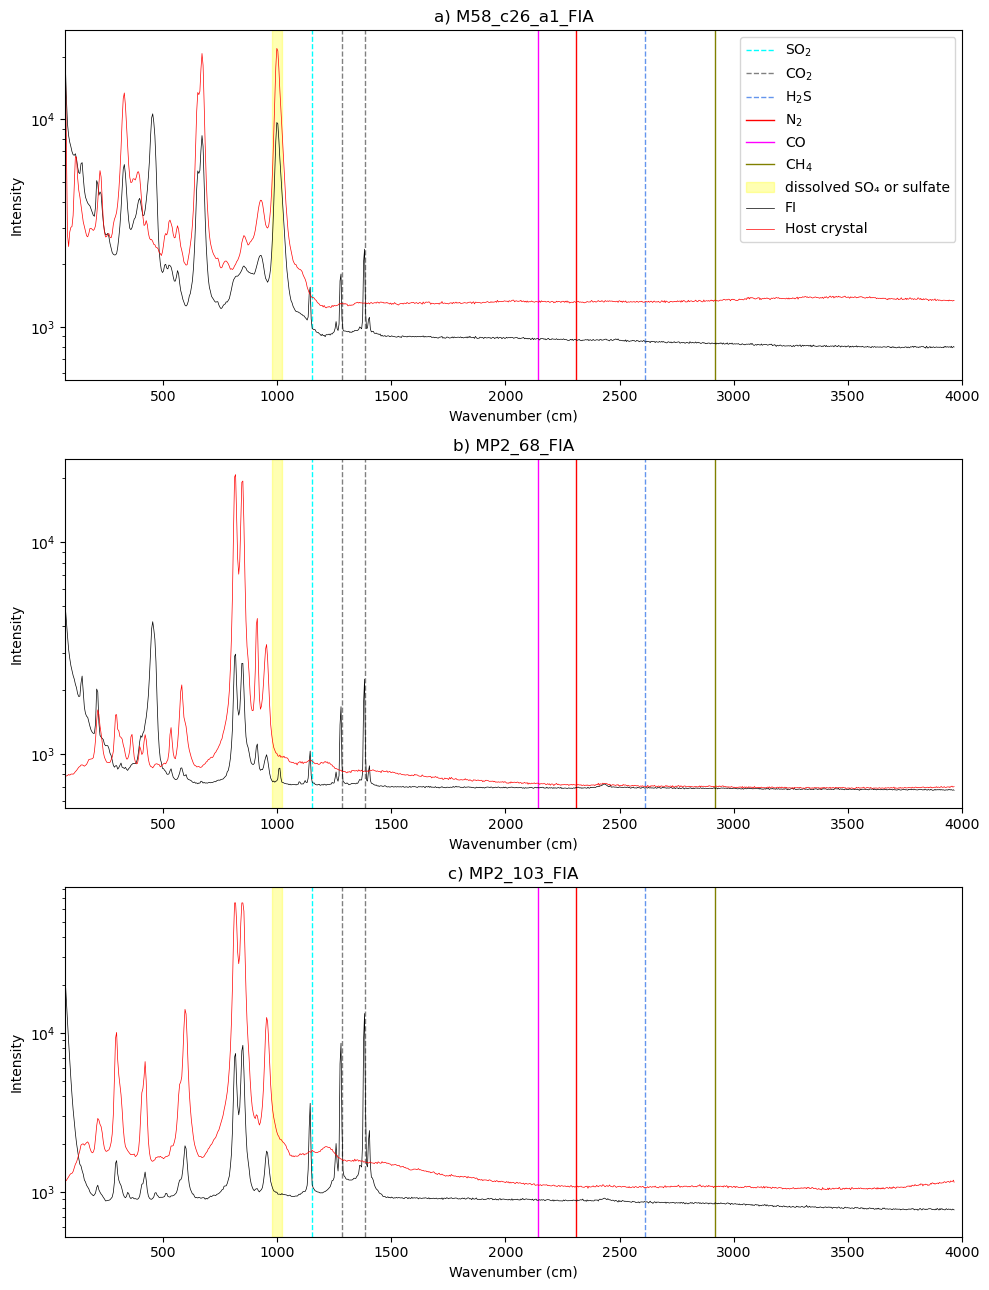

In [108]:
df_300g=pd.read_excel('Online_Resource_1.xlsx', sheet_name='300g_Scans')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (10,13))

for i, ax in enumerate([ax1, ax2, ax3]):
    ax.axvline(x=1151, color='k', linestyle='--', lw=1, c='cyan', label='SO$_2$')  # black dashed line
    ax.axvline(x=1284, color='k', linestyle='--', lw=1, c='grey', label='CO$_2$')  # black dashed line
    ax.axvline(x=1387, color='k', linestyle='--', lw=1, c='grey')  # black dashed line
    ax.axvline(x=2611, color='k', linestyle='--', lw=1, c='cornflowerblue', label='H$_2$S')  # black dashed line
    ax.axvline(x=2311, color='k', linestyle='-', lw=1, c='red', label='N$_2$')  # black dashed line
    ax.axvline(x=2143, color='k', linestyle='-', lw=1, c='magenta', label='CO')  # black dashed line    
    ax.axvline(x=2917, color='k', linestyle='-', lw=1, c='olive', label='CH$_4$')  # black dashed line   
    ax.axvspan(980, 1020, color='yellow', alpha=0.3, label='dissolved SO₄ or sulfate')
    ax.set_xlabel('Wavenumber (cm)')
    ax.set_ylabel('Intensity')
    if i==0:
        ax1.legend()

ax1.set_title('a) M58_c26_a1_FIA')
ax1.plot(df_300g['Wavenumber_07 300g_FI_M58_FI26'], 
         df_300g['Intensity_07 300g_FI_M58_FI26'], 
         '-k', label='FI',lw=0.5)
         

ax1.plot(df_300g['Wavenumber_08 300g_nearbyPX_M58_FI26'], 
         df_300g['Intensity_08 300g_nearbyPX_M58_FI26'], 
         '-r', label='Host crystal'
         , lw=0.5)
ax1.legend(loc='upper right', fontsize=10)
##########
ax2.set_title('b) MP2_68_FIA')
ax2.plot(df_300g['Wavenumber_MP2_68_FIA'], 
         df_300g['Intensity_MP2_68_FIA'], 
         '-k', label='FI MP2_68_FIA',lw=0.5)
         

ax2.plot(df_300g['Wavenumber_MP2_68_FIA_nearby_Ol'], 
         df_300g['Intensity_MP2_68_FIA_nearby_Ol'], 
         '-r', label='Olivine host'
         , lw=0.5)

##########
ax3.set_title('c) MP2_103_FIA')
ax3.plot(df_300g['Wavenumber_MP2_103_FIA'], 
         df_300g['Intensity_MP2_103_FIA'], 
         '-k', label='FI MP2_103_FIA',lw=0.5)
         

ax3.plot(df_300g['Wavenumber_MP2_103_FIA_nearbyOl'], 
         df_300g['Intensity_MP2_103_FIA_nearbyOl'], 
         '-r', label='Olivine host'
         , lw=0.5)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlim([70, 4000])
ax2.set_xlim([70, 4000])
ax3.set_xlim([70, 4000])
fig.tight_layout()
fig.savefig('300g_scans.png', dpi=300)


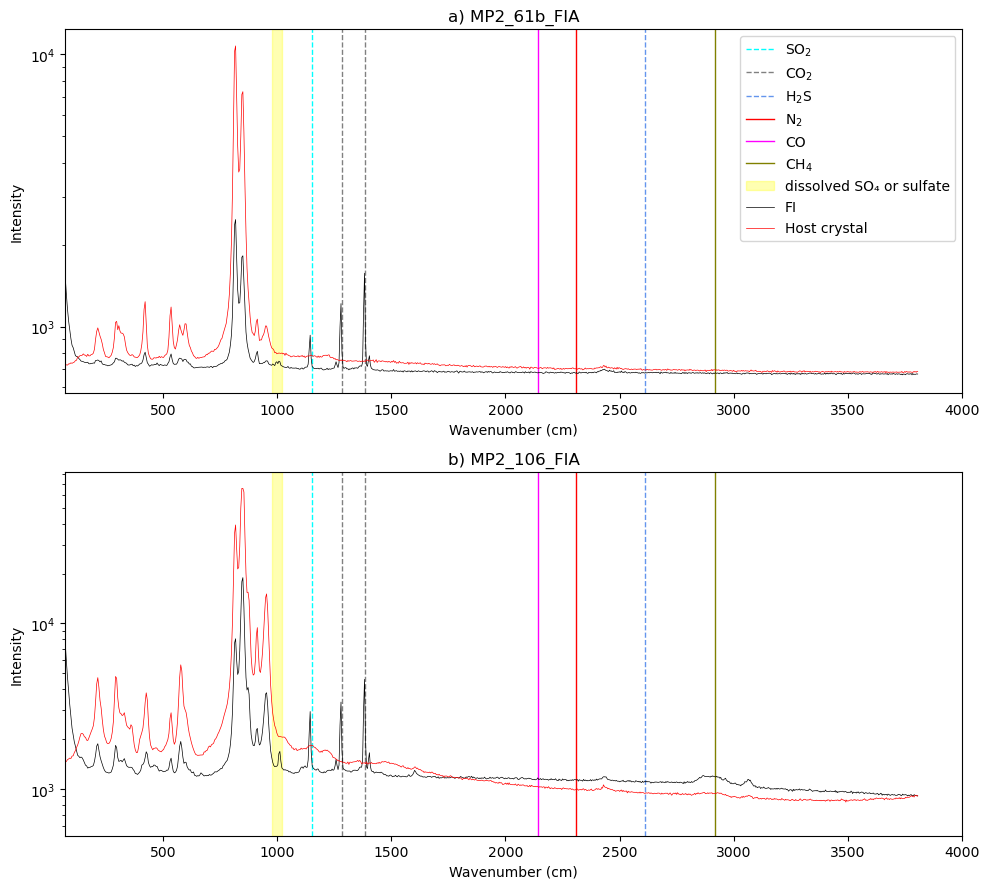

In [109]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10,9))

for i, ax in enumerate([ax1, ax2, ax3]):
    ax.axvline(x=1151, color='k', linestyle='--', lw=1, c='cyan', label='SO$_2$')  # black dashed line
    ax.axvline(x=1284, color='k', linestyle='--', lw=1, c='grey', label='CO$_2$')  # black dashed line
    ax.axvline(x=1387, color='k', linestyle='--', lw=1, c='grey')  # black dashed line
    ax.axvline(x=2611, color='k', linestyle='--', lw=1, c='cornflowerblue', label='H$_2$S')  # black dashed line
    ax.axvline(x=2311, color='k', linestyle='-', lw=1, c='red', label='N$_2$')  # black dashed line
    ax.axvline(x=2143, color='k', linestyle='-', lw=1, c='magenta', label='CO')  # black dashed line    
    ax.axvline(x=2917, color='k', linestyle='-', lw=1, c='olive', label='CH$_4$')  # black dashed line   
    ax.axvspan(980, 1020, color='yellow', alpha=0.3, label='dissolved SO₄ or sulfate')
    ax.set_xlabel('Wavenumber (cm)')
    ax.set_ylabel('Intensity')
    if i==0:
        ax1.legend()

ax1.set_title('a) MP2_61b_FIA')
ax1.plot(df_300g['Wavenumber_MP2_61b_FIA'], 
         df_300g['Intensity_MP2_61b_FIA'], 
         '-k', label='FI',lw=0.5)
         

ax1.plot(df_300g['Wavenumber_MP2_61b_FIA_nearbyOl'], 
         df_300g['Intensity_MP2_61b_FIA_nearbyOl'], 
         '-r', label='Host crystal'
         , lw=0.5)
ax1.legend(loc='upper right', fontsize=10)
##########
ax2.set_title('b) MP2_106_FIA')
ax2.plot(df_300g['Wavenumber_MP2_106_FIA'], 
         df_300g['Intensity_MP2_106_FIA'], 
         '-k', label='FI MP2_68_FIA',lw=0.5)
         

ax2.plot(df_300g['Wavenumber_MP2_106_FIA_nearbyOl'], 
         df_300g['Intensity_MP2_106_FIA_nearbyOl'], 
         '-r', label='Olivine host'
         , lw=0.5)



ax1.set_yscale('log')
ax2.set_yscale('log')

ax1.set_xlim([70, 4000])
ax2.set_xlim([70, 4000])

fig.tight_layout()
fig.savefig('300g_scans_2.png', dpi=300)

In [110]:
pf.convert_pressure_to_depth(P_kbar=2, model='denlinger_lerner')

0    7.484
dtype: float64

In [111]:
df_Opx=df_FI_ML.loc[df_FI_ML['Mineral_Host']=='Opx']
df_Opx['crystal'].value_counts()

crystal
M85_12     3
M49_2      2
M49_c52    1
M49_c55    1
M85_c52    1
M49_12     1
M49_3      1
M85_41     1
M85_44     1
M85_6      1
Name: count, dtype: int64

In [112]:
df_Opx=df_FI_ML.loc[df_FI_ML['Mineral_Host']=='Ol']
df_Opx['crystal'].value_counts()

crystal
MP2_64       11
AMG98_79e     8
MP2_61b       8
MP2_65        7
MP2_60        5
             ..
MLP_7         1
M58_c12       1
M58_c11       1
M58_c10       1
M58_c6        1
Name: count, Length: 139, dtype: int64

In [113]:
len(df_Opx['crystal'].unique())

139